## LIBRARIES

In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

## XAUUSD (GOLD)

In [65]:
# Option 1: Gold Futures (Most reliable and widely used on Yahoo Finance)
ticker = "GC=F"

# Option 2: Spot Gold / USD Pair (uncomment if you specifically need spot)
# ticker = "XAUUSD=X"

# Download historical data
gold_data = yf.download(
    tickers=ticker,
    period="max",        # Options: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
    interval="15m"       # Options: 1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo
)

gold_data.tail()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Datetime,,,,,
2026-10-05 11:45:00-04:00,4164.700195,4167.600098,4161.799805,4164.299805,1284
2026-10-05 12:00:00-04:00,4157.500000,4164.799805,4156.600098,4164.700195,942
2026-10-05 12:15:00-04:00,4155.200195,4158.100098,4153.600098,4157.399902,1399
2026-10-05 12:30:00-04:00,4158.899902,4159.299805,4155.000000,4155.299805,1043
2026-10-05 12:45:00-04:00,4158.700195,4159.299805,4156.299805,4158.799805,333


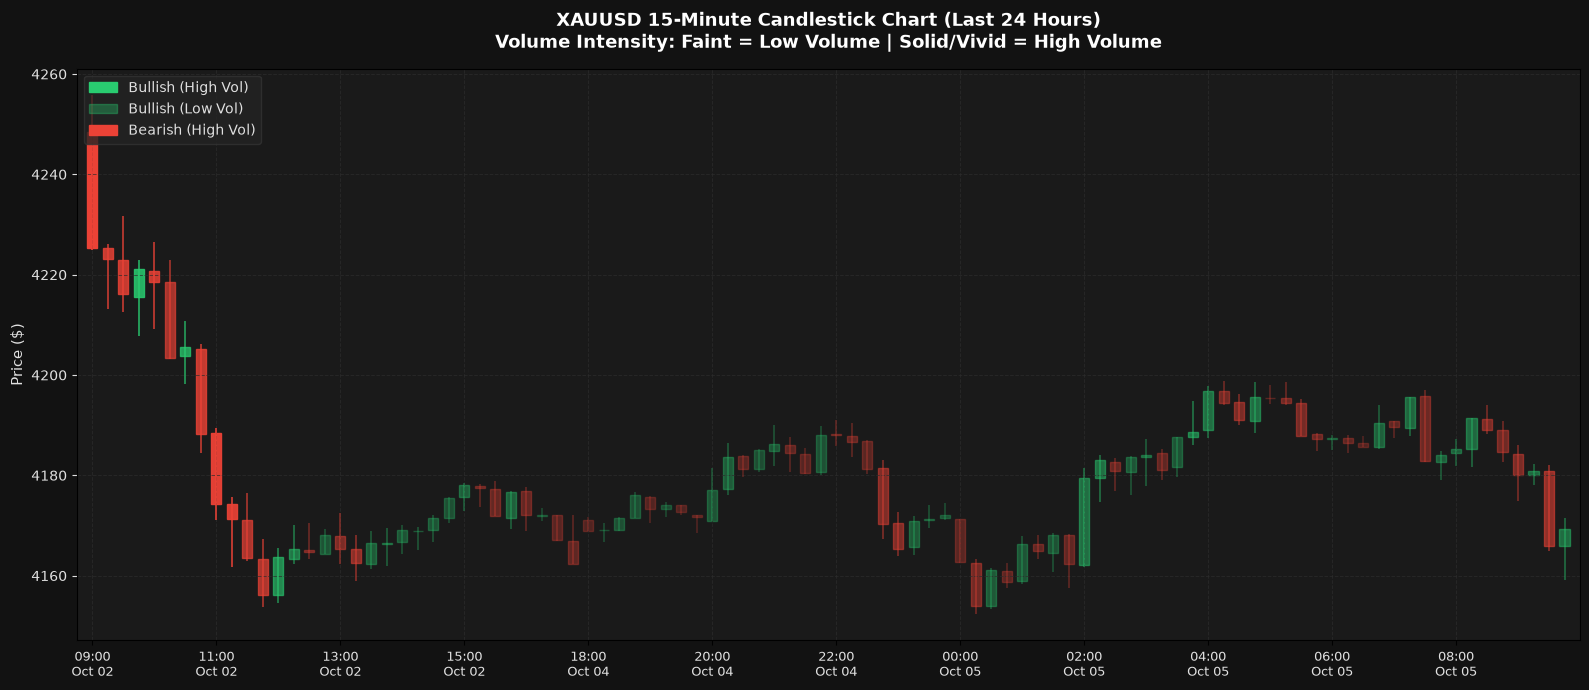

In [25]:
# ==========================================
# 1. PREPARE THE LAST 96 ROWS (24 HOURS)
# ==========================================
# Copy the last 96 rows
df_plot = gold_data.tail(96).copy()

# Flatten MultiIndex columns if present
if isinstance(df_plot.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)

# Normalize volume between 0.25 (faint) and 1.0 (vivid/intense)
vol_min = df_plot['Volume'].min()
vol_max = df_plot['Volume'].max()

# Handle edge case if volume is all zeros or constant
if vol_max > vol_min:
    norm_vol = 0.25 + 0.75 * ((df_plot['Volume'] - vol_min) / (vol_max - vol_min))
else:
    norm_vol = pd.Series(1.0, index=df_plot.index)

# ==========================================
# 2. PLOT CANDLESTICKS WITH VOLUME INTENSITY
# ==========================================
fig, ax = plt.subplots(figsize=(16, 7), facecolor='#121212')
ax.set_facecolor('#1a1a1a')

# Colors
UP_COLOR = np.array([0.16, 0.80, 0.44])    # Vibrant Green (RGB)
DOWN_COLOR = np.array([0.92, 0.26, 0.21])  # Vibrant Red (RGB)
bar_width = 0.65

# Plot each candle
for i in range(len(df_plot)):
    row = df_plot.iloc[i]
    alpha = float(norm_vol.iloc[i])
    
    is_up = row['Close'] >= row['Open']
    base_color = UP_COLOR if is_up else DOWN_COLOR
    
    # RGBA color with alpha dynamically mapped to volume
    candle_color = (base_color[0], base_color[1], base_color[2], alpha)
    
    # 1. Draw High-Low Wick
    ax.vlines(x=i, ymin=row['Low'], ymax=row['High'], color=candle_color, linewidth=1.2)
    
    # 2. Draw Open-Close Candle Body
    body_bottom = min(row['Open'], row['Close'])
    body_height = max(abs(row['Close'] - row['Open']), 0.1) # tiny height if doji
    
    rect = patches.Rectangle(
        xy=(i - bar_width / 2, body_bottom),
        width=bar_width,
        height=body_height,
        facecolor=candle_color,
        edgecolor=candle_color,
        linewidth=1
    )
    ax.add_patch(rect)

# ==========================================
# 3. FORMAT AXES & TICKS
# ==========================================
ax.set_xlim(-1, len(df_plot))
y_min = df_plot['Low'].min()
y_max = df_plot['High'].max()
y_pad = (y_max - y_min) * 0.05
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Label every 8 candles (every 2 hours) on the X-axis
tick_indices = list(range(0, len(df_plot), 8))
tick_labels = [df_plot.index[i].strftime('%H:%M\n%b %d') for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, color='#e0e0e0', fontsize=9)
ax.tick_params(axis='y', colors='#e0e0e0', labelsize=10)

# Styling and Grid
ax.grid(True, color='#2c2c2c', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_title("XAUUSD 15-Minute Candlestick Chart (Last 24 Hours)\nVolume Intensity: Faint = Low Volume | Solid/Vivid = High Volume", 
             color='#ffffff', fontsize=13, pad=15, fontweight='bold')
ax.set_ylabel("Price ($)", color='#e0e0e0', fontsize=11)

# Custom legend for volume explanation
green_patch = patches.Patch(color=(UP_COLOR[0], UP_COLOR[1], UP_COLOR[2], 1.0), label='Bullish (High Vol)')
faint_patch = patches.Patch(color=(UP_COLOR[0], UP_COLOR[1], UP_COLOR[2], 0.35), label='Bullish (Low Vol)')
red_patch   = patches.Patch(color=(DOWN_COLOR[0], DOWN_COLOR[1], DOWN_COLOR[2], 1.0), label='Bearish (High Vol)')

legend = ax.legend(handles=[green_patch, faint_patch, red_patch], 
                   facecolor='#242424', edgecolor='#333333', 
                   labelcolor='#e0e0e0', loc='upper left')

plt.tight_layout()
plt.show()


In [17]:
gold_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
count,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000
mean,4419.436179,4423.835324,4414.986799,4419.478780,1792.625433
std,138.940063,139.188044,138.684487,138.896963,1938.533921
min,4146.899902,4148.799805,4143.100098,4146.799805,1.000000
25%,4336.899902,4340.600098,4332.849854,4336.800049,785.000000
50%,4409.799805,4415.000000,4405.299805,4410.000000,1270.000000
75%,4479.150146,4484.200195,4475.550049,4479.300049,2115.000000
max,4751.299805,4755.000000,4740.700195,4751.500000,31938.000000


In [29]:
from statsmodels.tsa.stattools import adfuller

# 1. Clean columns if yfinance created MultiIndex headers
df_to_test = gold_data.copy()
if isinstance(df_to_test.columns, pd.MultiIndex):
    df_to_test.columns = df_to_test.columns.get_level_values(0)

# Drop any potential NaN values
df_to_test = df_to_test.dropna()

# 2. Features to test
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# 3. Run ADF Test on each feature
results = []
for feat in features:
    series = df_to_test[feat]
    
    # Run Augmented Dickey-Fuller Test
    # autolag='AIC' chooses the optimal number of lags automatically
    adf_result = adfuller(series, autolag='AIC')
    
    test_statistic = adf_result[0]
    p_value = adf_result[1]
    lags_used = adf_result[2]
    crit_value_1 = adf_result[4]['1%']
    crit_value_5 = adf_result[4]['5%']
    
    # Decision rule: p <= 0.05 rejects H0 (Series is Stationary)
    is_stationary = "Stationary" if p_value <= 0.05 else "Non-Stationary"
    
    results.append({
        'Feature': feat,
        'ADF Statistic': round(test_statistic, 4),
        'p-value': round(p_value, 4),
        '5% Critical Value': round(crit_value_5, 4),
        'Lags Used': lags_used,
        'Stationarity Status': is_stationary
    })

# 4. Display as a clean summary table
summary_df = pd.DataFrame(results)
print("=== ADF Stationarity Test Results (Raw Features) ===")
print(summary_df.to_string(index=False))


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3719513140.py:21: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3719513140.py:21: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\371951

=== ADF Stationarity Test Results (Raw Features) ===
Feature  ADF Statistic  p-value  5% Critical Value  Lags Used Stationarity Status
   Open        -0.8799   0.7945            -2.8623          0      Non-Stationary
   High        -1.0069   0.7507            -2.8623          7      Non-Stationary
    Low        -0.9287   0.7784            -2.8623         11      Non-Stationary
  Close        -0.9029   0.7870            -2.8623          0      Non-Stationary
 Volume       -14.0332   0.0000            -2.8623         10          Stationary


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3719513140.py:21: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(series, autolag='AIC')


In [30]:
# 1. Clean columns if MultiIndex
df_diff_test = gold_data.copy()
if isinstance(df_diff_test.columns, pd.MultiIndex):
    df_diff_test.columns = df_diff_test.columns.get_level_values(0)

price_features = ['Open', 'High', 'Low', 'Close']
max_diff = 2  # Test d = 0 (raw), d = 1 (first diff), d = 2 (second diff)

results = []

for feat in price_features:
    series = df_diff_test[feat].dropna()
    
    for d in range(max_diff + 1):
        if d == 0:
            diff_series = series
            diff_label = "d = 0 (Raw)"
        else:
            diff_series = series.diff(d).dropna()
            diff_label = f"d = {d} (Diff {d})"
        
        # Run ADF Test
        adf_res = adfuller(diff_series, autolag='AIC')
        stat = adf_res[0]
        p_val = adf_res[1]
        crit_5 = adf_res[4]['5%']
        is_stat = "Stationary" if p_val <= 0.05 else "Non-Stationary"
        
        results.append({
            'Feature': feat,
            'Differencing Order': diff_label,
            'ADF Statistic': round(stat, 4),
            'p-value': round(p_val, 6),
            '5% Critical': round(crit_5, 4),
            'Status': is_stat
        })

# 2. Display summary table
diff_summary_df = pd.DataFrame(results)
print("=== ADF Differencing Order Test ===")
print(diff_summary_df.to_string(index=False))

# 3. Find the minimum differencing required for each feature
print("\n=== Minimum Differencing Order (Integration Order I(d)) ===")
for feat in price_features:
    stat_rows = diff_summary_df[(diff_summary_df['Feature'] == feat) & (diff_summary_df['Status'] == 'Stationary')]
    if not stat_rows.empty:
        min_order = stat_rows.iloc[0]['Differencing Order']
        print(f"-> {feat}: {min_order}")
    else:
        print(f"-> {feat}: Not stationary within d = {max_diff}")


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1985151626.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1985151626.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\19

=== ADF Differencing Order Test ===
Feature Differencing Order  ADF Statistic  p-value  5% Critical         Status
   Open        d = 0 (Raw)        -0.8799 0.794511      -2.8623 Non-Stationary
   Open     d = 1 (Diff 1)       -61.2164 0.000000      -2.8623     Stationary
   Open     d = 2 (Diff 2)       -10.4293 0.000000      -2.8623     Stationary
   High        d = 0 (Raw)        -1.0069 0.750742      -2.8623 Non-Stationary
   High     d = 1 (Diff 1)       -21.7945 0.000000      -2.8623     Stationary
   High     d = 2 (Diff 2)       -10.0068 0.000000      -2.8623     Stationary
    Low        d = 0 (Raw)        -0.9287 0.778366      -2.8623 Non-Stationary
    Low     d = 1 (Diff 1)       -18.6376 0.000000      -2.8623     Stationary
    Low     d = 2 (Diff 2)       -10.5342 0.000000      -2.8623     Stationary
  Close        d = 0 (Raw)        -0.9029 0.787008      -2.8623 Non-Stationary
  Close     d = 1 (Diff 1)       -61.7559 0.000000      -2.8623     Stationary
  Close     d = 

C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1985151626.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1985151626.py:23: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')


In [32]:
# 1. Start with clean copy of gold_data
df = gold_data.copy()
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Apply 1st differencing ONLY to the non-stationary price columns
stationary_df = pd.DataFrame(index=df.index)

# First differences: delta_price = Price_t - Price_{t-1}
stationary_df['Open_diff1']  = df['Open'].diff(1)
stationary_df['High_diff1']  = df['High'].diff(1)
stationary_df['Low_diff1']   = df['Low'].diff(1)
stationary_df['Close_diff1'] = df['Close'].diff(1)

# Keep Volume UN-DIFFERENCED (already stationary)
# We can also add Log_Volume as a standardizing alternative
stationary_df['Volume'] = df['Volume']
stationary_df['Log_Volume'] = np.log1p(df['Volume'])

# 3. Align datetime: Drop the 1st row (which contains NaN from diff)
gold_data_stationary = stationary_df.dropna()

print(f"Original rows:   {len(df)}")
print(f"Stationary rows: {len(gold_data_stationary)} (lost exactly 1 row from diff)")
print("\nFirst 5 rows of stationary dataset:")
gold_data_stationary.tail()


Original rows:   3751
Stationary rows: 3750 (lost exactly 1 row from diff)

First 5 rows of stationary dataset:


,Open_diff1,High_diff1,Low_diff1,Close_diff1,Volume,Log_Volume
Datetime,,,,,,
2026-10-05 08:45:00-04:00,-2.200195,-3.100098,-5.600098,-4.399902,1502,7.315218
2026-10-05 09:00:00-04:00,-4.700195,-4.799805,-7.800293,-4.500000,1886,7.542744
2026-10-05 09:15:00-04:00,-4.299805,-3.800293,3.300293,0.799805,1649,7.408531
2026-10-05 09:30:00-04:00,0.799805,-0.299805,-13.100098,-15.000000,2785,7.932362
2026-10-05 09:45:00-04:00,-14.899902,-10.600098,-5.899902,3.500000,1930,7.565793


## XAGUSD (SILVER)

In [66]:
# Option 1: Silver Futures (Most reliable and widely used on Yahoo Finance)
ticker = "SI=F"

# Download historical data
silver_data = yf.download(
    tickers=ticker,
    period="max",        # Options: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
    interval="15m"       # Options: 1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo
)

silver_data.tail()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SI=F,SI=F,SI=F,SI=F,SI=F
Datetime,,,,,
2026-10-05 11:45:00-04:00,61.490002,61.540001,61.455002,61.509998,239
2026-10-05 12:00:00-04:00,61.330002,61.490002,61.299999,61.485001,282
2026-10-05 12:15:00-04:00,61.255001,61.355000,61.250000,61.325001,273
2026-10-05 12:30:00-04:00,61.320000,61.349998,61.205002,61.264999,465
2026-10-05 12:45:00-04:00,61.334999,61.345001,61.279999,61.325001,73


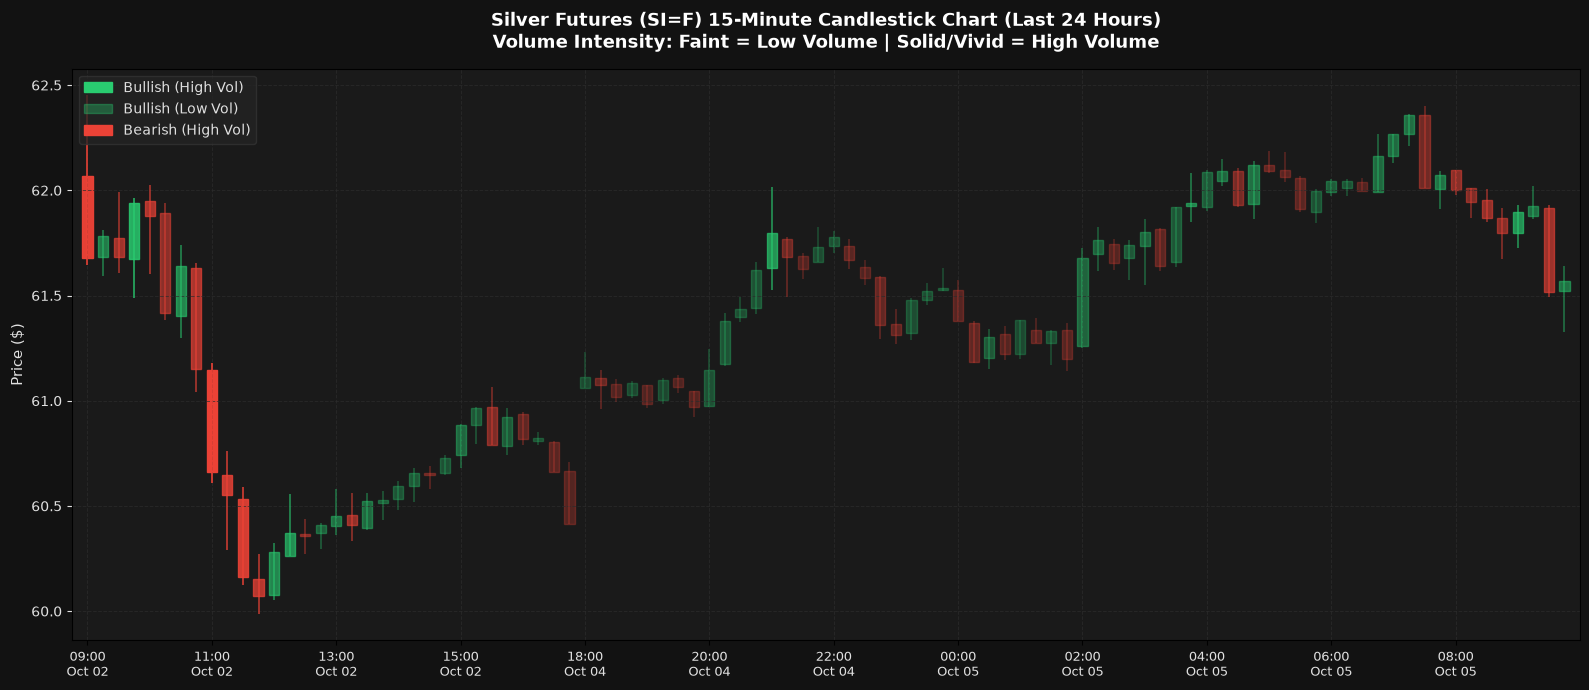

In [26]:
# ==========================================
# 1. PREPARE THE LAST 96 ROWS (24 HOURS)
# ==========================================
df_plot = silver_data.tail(96).copy()

# Flatten MultiIndex columns if present
if isinstance(df_plot.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)

# Normalize volume between 0.25 (faint) and 1.0 (vivid/intense)
vol_min = df_plot['Volume'].min()
vol_max = df_plot['Volume'].max()

if vol_max > vol_min:
    norm_vol = 0.25 + 0.75 * ((df_plot['Volume'] - vol_min) / (vol_max - vol_min))
else:
    norm_vol = pd.Series(1.0, index=df_plot.index)

# ==========================================
# 2. PLOT CANDLESTICKS WITH VOLUME INTENSITY
# ==========================================
fig, ax = plt.subplots(figsize=(16, 7), facecolor='#121212')
ax.set_facecolor('#1a1a1a')

# Colors
UP_COLOR = np.array([0.16, 0.80, 0.44])    # Vibrant Green (RGB)
DOWN_COLOR = np.array([0.92, 0.26, 0.21])  # Vibrant Red (RGB)
bar_width = 0.65

# Dynamic minimum body height for doji candles (silver prices are in tens of dollars)
y_min = df_plot['Low'].min()
y_max = df_plot['High'].max()
min_body = (y_max - y_min) * 0.005

# Plot each candle
for i in range(len(df_plot)):
    row = df_plot.iloc[i]
    alpha = float(norm_vol.iloc[i])
    
    is_up = row['Close'] >= row['Open']
    base_color = UP_COLOR if is_up else DOWN_COLOR
    
    # RGBA color with alpha dynamically mapped to volume
    candle_color = (base_color[0], base_color[1], base_color[2], alpha)
    
    # 1. Draw High-Low Wick
    ax.vlines(x=i, ymin=row['Low'], ymax=row['High'], color=candle_color, linewidth=1.2)
    
    # 2. Draw Open-Close Candle Body
    body_bottom = min(row['Open'], row['Close'])
    body_height = max(abs(row['Close'] - row['Open']), min_body)
    
    rect = patches.Rectangle(
        xy=(i - bar_width / 2, body_bottom),
        width=bar_width,
        height=body_height,
        facecolor=candle_color,
        edgecolor=candle_color,
        linewidth=1
    )
    ax.add_patch(rect)

# ==========================================
# 3. FORMAT AXES & TICKS
# ==========================================
ax.set_xlim(-1, len(df_plot))
y_pad = (y_max - y_min) * 0.05
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Label every 8 candles (every 2 hours) on the X-axis
tick_indices = list(range(0, len(df_plot), 8))
tick_labels = [df_plot.index[i].strftime('%H:%M\n%b %d') for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, color='#e0e0e0', fontsize=9)
ax.tick_params(axis='y', colors='#e0e0e0', labelsize=10)

# Styling and Grid
ax.grid(True, color='#2c2c2c', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_title("Silver Futures (SI=F) 15-Minute Candlestick Chart (Last 24 Hours)\nVolume Intensity: Faint = Low Volume | Solid/Vivid = High Volume", 
             color='#ffffff', fontsize=13, pad=15, fontweight='bold')
ax.set_ylabel("Price ($)", color='#e0e0e0', fontsize=11)

# Custom legend for volume explanation
green_patch = patches.Patch(color=(UP_COLOR[0], UP_COLOR[1], UP_COLOR[2], 1.0), label='Bullish (High Vol)')
faint_patch = patches.Patch(color=(UP_COLOR[0], UP_COLOR[1], UP_COLOR[2], 0.35), label='Bullish (Low Vol)')
red_patch   = patches.Patch(color=(DOWN_COLOR[0], DOWN_COLOR[1], DOWN_COLOR[2], 1.0), label='Bearish (High Vol)')

legend = ax.legend(handles=[green_patch, faint_patch, red_patch], 
                   facecolor='#242424', edgecolor='#333333', 
                   labelcolor='#e0e0e0', loc='upper left')

plt.tight_layout()
plt.show()


In [19]:
silver_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,SI=F,SI=F,SI=F,SI=F,SI=F
count,3753.000000,3753.000000,3753.000000,3753.000000,3753.00000
mean,65.451524,65.563068,65.338491,65.451997,518.92486
std,2.398942,2.409174,2.390483,2.398826,606.15827
min,60.070000,60.270000,59.985001,60.075001,0.00000
25%,64.070000,64.169998,63.950001,64.065002,169.00000
50%,65.434998,65.555000,65.294998,65.430000,329.00000
75%,67.129997,67.239998,67.004997,67.129997,657.00000
max,71.625000,72.050003,71.434998,71.629997,9721.00000


In [34]:
# ==========================================
# 1. CLEAN SILVER DATA COLUMNS
# ==========================================
df_silver = silver_data.copy()
if isinstance(df_silver.columns, pd.MultiIndex):
    df_silver.columns = df_silver.columns.get_level_values(0)

features = ['Open', 'High', 'Low', 'Close', 'Volume']

# ==========================================
# 2. TEST STATIONARITY OF RAW FEATURES (d = 0)
# ==========================================
print("=== 1. Silver Raw Features ADF Test ===")
raw_results = []
for feat in features:
    series = df_silver[feat].dropna()
    adf_res = adfuller(series, autolag='AIC')
    stat, p_val, lags = adf_res[0], adf_res[1], adf_res[2]
    crit_5 = adf_res[4]['5%']
    is_stat = "Stationary" if p_val <= 0.05 else "Non-Stationary"
    
    raw_results.append({
        'Feature': feat,
        'ADF Stat': round(stat, 4),
        'p-value': round(p_val, 4),
        '5% Critical': round(crit_5, 4),
        'Lags': lags,
        'Status': is_stat
    })

raw_df = pd.DataFrame(raw_results)
print(raw_df.to_string(index=False))

# ==========================================
# 3. TEST DIFFERENCING ORDER FOR NON-STATIONARY (d = 1, 2)
# ==========================================
price_features = ['Open', 'High', 'Low', 'Close']
print("\n=== 2. Testing Differencing Orders (d = 1, d = 2) ===")

diff_results = []
for feat in price_features:
    series = df_silver[feat].dropna()
    for d in [1, 2]:
        diff_series = series.diff(d).dropna()
        adf_res = adfuller(diff_series, autolag='AIC')
        stat, p_val = adf_res[0], adf_res[1]
        is_stat = "Stationary" if p_val <= 0.05 else "Non-Stationary"
        
        diff_results.append({
            'Feature': feat,
            'Order': f"d = {d}",
            'ADF Stat': round(stat, 4),
            'p-value': round(p_val, 6),
            'Status': is_stat
        })

diff_df = pd.DataFrame(diff_results)
print(diff_df.to_string(index=False))

# ==========================================
# 4. CREATE CLEAN STATIONARY SILVER DATAFRAME
# ==========================================
silver_data_stationary = pd.DataFrame(index=df_silver.index)

# Apply 1st differencing to prices
silver_data_stationary['Silver_Open_diff1']  = df_silver['Open'].diff(1)
silver_data_stationary['Silver_High_diff1']  = df_silver['High'].diff(1)
silver_data_stationary['Silver_Low_diff1']   = df_silver['Low'].diff(1)
silver_data_stationary['Silver_Close_diff1'] = df_silver['Close'].diff(1)

# Keep Volume un-differenced (it is already stationary)
silver_data_stationary['Silver_Volume']     = df_silver['Volume']
silver_data_stationary['Silver_Log_Volume'] = np.log1p(df_silver['Volume'])

# Drop the first NaN row from differencing to align timestamps
silver_data_stationary = silver_data_stationary.dropna()

print(f"\n=== 3. Stationary Silver Dataset Created ===")
print(f"Total rows: {len(silver_data_stationary)}")
silver_data_stationary.tail()


=== 1. Silver Raw Features ADF Test ===


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.p

Feature  ADF Stat  p-value  5% Critical  Lags         Status
   Open   -2.0703   0.2566      -2.8623     1 Non-Stationary
   High   -2.2366   0.1932      -2.8623     7 Non-Stationary
    Low   -2.1384   0.2294      -2.8623    13 Non-Stationary
  Close   -2.0769   0.2539      -2.8623     1 Non-Stationary
 Volume  -11.7494   0.0000      -2.8623    30     Stationary

=== 2. Testing Differencing Orders (d = 1, d = 2) ===


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.py:45: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.py:45: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\33

Feature Order  ADF Stat  p-value     Status
   Open d = 1  -62.7649      0.0 Stationary
   Open d = 2  -10.4039      0.0 Stationary
   High d = 1  -21.8157      0.0 Stationary
   High d = 2  -10.3282      0.0 Stationary
    Low d = 1  -16.7857      0.0 Stationary
    Low d = 2  -10.8505      0.0 Stationary
  Close d = 1  -63.6935      0.0 Stationary
  Close d = 2  -10.3464      0.0 Stationary

=== 3. Stationary Silver Dataset Created ===
Total rows: 3752


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.py:45: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\3346676172.py:45: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(diff_series, autolag='AIC')


,Silver_Open_diff1,Silver_High_diff1,Silver_Low_diff1,Silver_Close_diff1,Silver_Volume,Silver_Log_Volume
Datetime,,,,,,
2026-10-05 08:45:00-04:00,-0.085003,-0.090000,-0.174999,-0.075001,697,6.548219
2026-10-05 09:00:00-04:00,-0.075001,0.014999,0.049999,0.100002,1035,6.943122
2026-10-05 09:15:00-04:00,0.085003,0.090000,0.140003,0.029999,552,6.315358
2026-10-05 09:30:00-04:00,0.035000,-0.090000,-0.370003,-0.410000,938,6.844815
2026-10-05 09:45:00-04:00,-0.395000,-0.290001,-0.169998,0.055000,610,6.415097


## GRANGER-CAUSALITY

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests

# ==========================================
# 1. PREPARE THE STATIONARY COLUMNS
# ==========================================
# In statsmodels grangercausalitytests:
# Column 0 = Target (Effect, y)
# Column 1 = Predictor (Cause, x)

data_silver_to_gold = merged_df[['Gold_Close_diff1', 'Silver_Close_diff1']]
data_gold_to_silver = merged_df[['Silver_Close_diff1', 'Gold_Close_diff1']]

max_lags = 8  # 8 lags * 15 min = 2 hours

# ==========================================
# 2. RUN GRANGER CAUSALITY FUNCTION
# ==========================================
def run_gc_summary(data_subset, target_name, predictor_name, max_lags=8):
    print(f"\n{'='*60}")
    print(f"Testing: Does [{predictor_name}] Granger-Cause [{target_name}]?")
    print(f"{'='*60}")
    
    # In newer statsmodels, omit 'verbose'
    gc_res = grangercausalitytests(data_subset, maxlag=max_lags)
    
    summary = []
    for lag, res in gc_res.items():
        f_stat = res[0]['ssr_ftest'][0]
        f_pvalue = res[0]['ssr_ftest'][1]
        chi2_stat = res[0]['ssr_chi2test'][0]
        chi2_pvalue = res[0]['ssr_chi2test'][1]
        
        is_causal = "YES (Predictive)" if f_pvalue < 0.05 else "No"
        
        summary.append({
            'Lag': lag,
            'Lookback (min)': lag * 15,
            'F-Statistic': round(f_stat, 4),
            'F-Test p-value': round(f_pvalue, 6),
            'Chi2 p-value': round(chi2_pvalue, 6),
            'Granger Causes?': is_causal
        })
    
    return pd.DataFrame(summary)

# ==========================================
# 3. DISPLAY RESULTS
# ==========================================
# 1. Does Silver lead Gold?
silver_causes_gold_df = run_gc_summary(
    data_silver_to_gold, 
    target_name='Gold_Close_diff1', 
    predictor_name='Silver_Close_diff1', 
    max_lags=max_lags
)
print(silver_causes_gold_df.to_string(index=False))

# 2. Does Gold lead Silver?
gold_causes_silver_df = run_gc_summary(
    data_gold_to_silver, 
    target_name='Silver_Close_diff1', 
    predictor_name='Gold_Close_diff1', 
    max_lags=max_lags
)
print(gold_causes_silver_df.to_string(index=False))



Testing: Does [Silver_Close_diff1] Granger-Cause [Gold_Close_diff1]?
 Lag  Lookback (min)  F-Statistic  F-Test p-value  Chi2 p-value Granger Causes?
   1              15       0.0138        0.906575      0.906532              No
   2              30       0.8902        0.410665      0.410090              No
   3              45       0.8370        0.473415      0.472478              No
   4              60       0.8673        0.482699      0.481316              No
   5              75       0.7315        0.599735      0.598077              No
   6              90       0.7214        0.632330      0.630275              No
   7             105       0.7474        0.631716      0.629133              No
   8             120       0.8065        0.596815      0.593499              No

Testing: Does [Gold_Close_diff1] Granger-Cause [Silver_Close_diff1]?
 Lag  Lookback (min)  F-Statistic  F-Test p-value  Chi2 p-value  Granger Causes?
   1              15       3.5371        0.060088      0.05

##### Gold granger-caused silver at 30, 45, and 60 minutes, not the other way around in closing prices.

In [41]:
from statsmodels.tsa.stattools import grangercausalitytests

# Helper function to run and format Granger Causality results
def test_granger_bivariate(df, target_col, predictor_col, max_lags=8):
    data_subset = df[[target_col, predictor_col]]
    gc_res = grangercausalitytests(data_subset, maxlag=max_lags)
    
    records = []
    for lag, res in gc_res.items():
        f_stat = res[0]['ssr_ftest'][0]
        f_pvalue = res[0]['ssr_ftest'][1]
        chi2_pvalue = res[0]['ssr_chi2test'][1]
        
        is_causal = "YES (Predictive)" if f_pvalue < 0.05 else "No"
        
        records.append({
            'Lag': lag,
            'Minutes': lag * 15,
            'F-Statistic': round(f_stat, 4),
            'p-value (F-test)': round(f_pvalue, 6),
            'p-value (Chi2)': round(chi2_pvalue, 6),
            'Granger Causes?': is_causal
        })
    return pd.DataFrame(records)

# ==========================================
# 1. TEST HIGHS (Both Directions)
# ==========================================
print("\n" + "="*65)
print("TEST 1: Does SILVER High lead GOLD High?")
print("="*65)
df_silver_leads_gold_high = test_granger_bivariate(
    merged_df, target_col='Gold_High_diff1', predictor_col='Silver_High_diff1', max_lags=8
)
print(df_silver_leads_gold_high.to_string(index=False))

print("\n" + "="*65)
print("TEST 2: Does GOLD High lead SILVER High?")
print("="*65)
df_gold_leads_silver_high = test_granger_bivariate(
    merged_df, target_col='Silver_High_diff1', predictor_col='Gold_High_diff1', max_lags=8
)
print(df_gold_leads_silver_high.to_string(index=False))

# ==========================================
# 2. TEST LOWS (Both Directions)
# ==========================================
print("\n" + "="*65)
print("TEST 3: Does SILVER Low lead GOLD Low?")
print("="*65)
df_silver_leads_gold_low = test_granger_bivariate(
    merged_df, target_col='Gold_Low_diff1', predictor_col='Silver_Low_diff1', max_lags=8
)
print(df_silver_leads_gold_low.to_string(index=False))

print("\n" + "="*65)
print("TEST 4: Does GOLD Low lead SILVER Low?")
print("="*65)
df_gold_leads_silver_low = test_granger_bivariate(
    merged_df, target_col='Silver_Low_diff1', predictor_col='Gold_Low_diff1', max_lags=8
)
print(df_gold_leads_silver_low.to_string(index=False))



TEST 1: Does SILVER High lead GOLD High?
 Lag  Minutes  F-Statistic  p-value (F-test)  p-value (Chi2) Granger Causes?
   1       15       3.4679          0.062649        0.062466              No
   2       30       2.6875          0.068182        0.067807              No
   3       45       2.0574          0.103724        0.103008              No
   4       60       1.5819          0.176231        0.174970              No
   5       75       1.3813          0.227971        0.226145              No
   6       90       1.1796          0.313983        0.311479              No
   7      105       1.1383          0.335723        0.332605              No
   8      120       1.0603          0.388082        0.384290              No

TEST 2: Does GOLD High lead SILVER High?
 Lag  Minutes  F-Statistic  p-value (F-test)  p-value (Chi2)  Granger Causes?
   1       15       4.1205          0.042437        0.042284 YES (Predictive)
   2       30       4.1873          0.015259        0.015103 YES (P

##### Gold high leads silver high (up to 105 mins), silver low leads gold low (up to 120 mins).
##### Macro bullish shock - Gold is bought first, followed by Silver, Liquidity Canary - Silver cracks first before Gold because Gold has more buyers to absorb the selling.

In [42]:
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

# ==========================================
# 1. COMPUTE RANGES (VOLATILITY) AND MERGE
# ==========================================
# Flatten column headers if present
df_gold_raw = gold_data.copy()
if isinstance(df_gold_raw.columns, pd.MultiIndex):
    df_gold_raw.columns = df_gold_raw.columns.get_level_values(0)

df_silver_raw = silver_data.copy()
if isinstance(df_silver_raw.columns, pd.MultiIndex):
    df_silver_raw.columns = df_silver_raw.columns.get_level_values(0)

# Candle Range = High - Low (the true measure of 15m volatility)
df_spillover = pd.DataFrame(index=df_gold_raw.index)
df_spillover['Gold_Range'] = df_gold_raw['High'] - df_gold_raw['Low']
df_spillover['Gold_Volume'] = df_gold_raw['Volume']
df_spillover['Gold_Log_Volume'] = np.log1p(df_gold_raw['Volume'])

df_silver_temp = pd.DataFrame(index=df_silver_raw.index)
df_silver_temp['Silver_Range'] = df_silver_raw['High'] - df_silver_raw['Low']
df_silver_temp['Silver_Volume'] = df_silver_raw['Volume']
df_silver_temp['Silver_Log_Volume'] = np.log1p(df_silver_raw['Volume'])

# Inner merge to synchronize timestamps
merged_spillover = pd.merge(df_spillover, df_silver_temp, left_index=True, right_index=True, how='inner').dropna()

# ==========================================
# 2. CHECK STATIONARITY OF RANGES
# ==========================================
print("=== Checking Stationarity of Candle Ranges ===")
for col in ['Gold_Range', 'Silver_Range']:
    stat, pval = adfuller(merged_spillover[col])[0], adfuller(merged_spillover[col])[1]
    print(f"{col}: ADF = {stat:.4f}, p-value = {pval:.6f} -> {'Stationary' if pval <= 0.05 else 'Non-Stationary'}")

# ==========================================
# 3. HELPER FUNCTION FOR GRANGER SUMMARY
# ==========================================
def test_granger_spillover(df, target_col, predictor_col, max_lags=8):
    data_subset = df[[target_col, predictor_col]]
    gc_res = grangercausalitytests(data_subset, maxlag=max_lags)
    
    records = []
    for lag, res in gc_res.items():
        f_stat = res[0]['ssr_ftest'][0]
        f_pvalue = res[0]['ssr_ftest'][1]
        chi2_pvalue = res[0]['ssr_chi2test'][1]
        
        is_causal = "YES (Predictive)" if f_pvalue < 0.05 else "No"
        
        records.append({
            'Lag': lag,
            'Minutes': lag * 15,
            'F-Statistic': round(f_stat, 4),
            'p-value (F-test)': round(f_pvalue, 6),
            'Granger Causes?': is_causal
        })
    return pd.DataFrame(records)

# ==========================================
# 4. PART A: VOLATILITY SPILLOVER (RANGE)
# ==========================================
print("\n" + "="*65)
print("TEST A1: Does SILVER Range Granger-cause GOLD Range?")
print("="*65)
df_silver_to_gold_range = test_granger_spillover(
    merged_spillover, target_col='Gold_Range', predictor_col='Silver_Range', max_lags=8
)
print(df_silver_to_gold_range.to_string(index=False))

print("\n" + "="*65)
print("TEST A2: Does GOLD Range Granger-cause SILVER Range?")
print("="*65)
df_gold_to_silver_range = test_granger_spillover(
    merged_spillover, target_col='Silver_Range', predictor_col='Gold_Range', max_lags=8
)
print(df_gold_to_silver_range.to_string(index=False))

# ==========================================
# 5. PART B: VOLUME-TO-VOLATILITY SPILLOVER
# ==========================================
print("\n" + "="*65)
print("TEST B1: Does SILVER Volume Granger-cause GOLD Range?")
print("="*65)
df_silver_vol_to_gold_range = test_granger_spillover(
    merged_spillover, target_col='Gold_Range', predictor_col='Silver_Log_Volume', max_lags=8
)
print(df_silver_vol_to_gold_range.to_string(index=False))

print("\n" + "="*65)
print("TEST B2: Does GOLD Volume Granger-cause SILVER Range?")
print("="*65)
df_gold_vol_to_silver_range = test_granger_spillover(
    merged_spillover, target_col='Silver_Range', predictor_col='Gold_Log_Volume', max_lags=8
)
print(df_gold_vol_to_silver_range.to_string(index=False))


=== Checking Stationarity of Candle Ranges ===


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1585832129.py:34: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval = adfuller(merged_spillover[col])[0], adfuller(merged_spillover[col])[1]
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1585832129.py:34: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval = adfuller(merged_spillover[col])[0], adfuller(merg

Gold_Range: ADF = -15.5548, p-value = 0.000000 -> Stationary


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1585832129.py:34: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval = adfuller(merged_spillover[col])[0], adfuller(merged_spillover[col])[1]
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\1585832129.py:34: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval = adfuller(merged_spillover[col])[0], adfuller(merg

Silver_Range: ADF = -11.6489, p-value = 0.000000 -> Stationary

TEST A1: Does SILVER Range Granger-cause GOLD Range?
 Lag  Minutes  F-Statistic  p-value (F-test)  Granger Causes?
   1       15      51.3301               0.0 YES (Predictive)
   2       30      21.9944               0.0 YES (Predictive)
   3       45      13.1912               0.0 YES (Predictive)
   4       60       9.8926               0.0 YES (Predictive)
   5       75       9.0532               0.0 YES (Predictive)
   6       90       7.9363               0.0 YES (Predictive)
   7      105       6.9362               0.0 YES (Predictive)
   8      120       6.1402               0.0 YES (Predictive)

TEST A2: Does GOLD Range Granger-cause SILVER Range?
 Lag  Minutes  F-Statistic  p-value (F-test)  Granger Causes?
   1       15      16.2585          0.000056 YES (Predictive)
   2       30       4.7884          0.008377 YES (Predictive)
   3       45       3.1214          0.024938 YES (Predictive)
   4       60       1.9

##### Silver is Gold's Volatility Canary (F = 51.33 vs 16.25 at lag 1): Silver's candle range expands first. When Silver's 15-minute candle stretch, Gold's next candle is "practically guaranteed" to expand its High-Low spread.
##### Silver Volume is the Volatility Detonator (F = 135.56): Silver_Log_Volume >>> Gold Range produced F=135.56 at lag 1. WHen trading volume spikes in Silver, Gold's High and Low will be forced to blow wide open over the next 15 to 60 minutes.

## XAUUSD + XAGUSD

In [37]:
# ==========================================
# 1. ENSURE DISTINCT COLUMN NAMES
# ==========================================
# Prefix gold columns with 'Gold_' if they aren't already prefixed
# (prevents any column name overlap with Silver)
gold_cols_to_merge = gold_data_stationary.copy()
if not any(col.startswith('Gold_') for col in gold_cols_to_merge.columns):
    gold_cols_to_merge = gold_cols_to_merge.add_prefix('Gold_')

silver_cols_to_merge = silver_data_stationary.copy()
if not any(col.startswith('Silver_') for col in silver_cols_to_merge.columns):
    silver_cols_to_merge = silver_cols_to_merge.add_prefix('Silver_')

# ==========================================
# 2. INNER JOIN ON DATETIME INDEX
# ==========================================
# An inner join keeps only the timestamps where BOTH Gold and Silver traded
merged_df = pd.merge(
    gold_cols_to_merge,
    silver_cols_to_merge,
    left_index=True,
    right_index=True,
    how='inner'
)

# Sort index chronologically just to be sure
merged_df = merged_df.sort_index()

# ==========================================
# 3. VERIFY MERGED DATASET
# ==========================================
print("=== Merged Stationary Dataset Summary ===")
print(f"Gold rows:       {len(gold_cols_to_merge)}")
print(f"Silver rows:     {len(silver_cols_to_merge)}")
print(f"Merged rows:     {len(merged_df)} (perfect timestamp alignment)")
print(f"Total columns:   {merged_df.shape[1]}")
print(f"Any NaN values:  {merged_df.isna().sum().sum()}")

print("\nColumns in merged dataset:")
print(list(merged_df.columns))



=== Merged Stationary Dataset Summary ===
Gold rows:       3750
Silver rows:     3752
Merged rows:     3748 (perfect timestamp alignment)
Total columns:   12
Any NaN values:  0

Columns in merged dataset:
['Gold_Open_diff1', 'Gold_High_diff1', 'Gold_Low_diff1', 'Gold_Close_diff1', 'Gold_Volume', 'Gold_Log_Volume', 'Silver_Open_diff1', 'Silver_High_diff1', 'Silver_Low_diff1', 'Silver_Close_diff1', 'Silver_Volume', 'Silver_Log_Volume']


In [38]:
merged_df.tail(10)

,Gold_Open_diff1,Gold_High_diff1,Gold_Low_diff1,Gold_Close_diff1,Gold_Volume,Gold_Log_Volume,Silver_Open_diff1,Silver_High_diff1,Silver_Low_diff1,Silver_Close_diff1,Silver_Volume,Silver_Log_Volume
Datetime,,,,,,,,,,,,
2026-10-05 07:30:00-04:00,6.399902,1.500000,-5.199707,-12.800293,1294,7.166266,0.090000,0.035000,-0.200001,-0.350002,437,6.082219
2026-10-05 07:45:00-04:00,-13.099609,-12.200195,-3.600098,1.300293,1191,7.083388,-0.355000,-0.310001,-0.099998,0.065002,625,6.439350
2026-10-05 08:00:00-04:00,1.699707,2.399902,2.799805,1.100098,1172,7.067320,0.090000,0.005001,0.070000,-0.075001,709,6.565265
2026-10-05 08:15:00-04:00,0.800293,4.200195,-0.299805,6.299805,1775,7.482119,-0.085003,-0.085003,-0.110001,-0.055000,616,6.424869
2026-10-05 08:30:00-04:00,6.000000,2.500000,6.600098,-2.500000,1823,7.508787,-0.054996,-0.004997,-0.020000,-0.075001,798,6.683361
2026-10-05 08:45:00-04:00,-2.200195,-3.100098,-5.600098,-4.399902,1502,7.315218,-0.085003,-0.090000,-0.174999,-0.075001,697,6.548219
2026-10-05 09:00:00-04:00,-4.700195,-4.799805,-7.800293,-4.500000,1886,7.542744,-0.075001,0.014999,0.049999,0.100002,1035,6.943122
2026-10-05 09:15:00-04:00,-4.299805,-3.800293,3.300293,0.799805,1649,7.408531,0.085003,0.090000,0.140003,0.029999,552,6.315358
2026-10-05 09:30:00-04:00,0.799805,-0.299805,-13.100098,-15.000000,2785,7.932362,0.035000,-0.090000,-0.370003,-0.410000,938,6.844815


## LOCAL DATA LAKE

In [64]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import yfinance as yf
import pyarrow as pa
import pyarrow.parquet as pq

# ==========================================
# 1. DEFINE PATHS & TICKERS
# ==========================================
DATA_DIR = Path(r"D:\AA JOB JOB\projects\Statistics")
PARQUET_FILE = DATA_DIR / "market_data_15m.parquet"
DATA_DIR.mkdir(parents=True, exist_ok=True)

TICKER_GOLD = "GC=F"
TICKER_SILVER = "SI=F"

# ==========================================
# 2. HELPER: FETCH AND CLEAN
# ==========================================
def fetch_clean_ticker(ticker, period="60d", interval="15m", prefix=""):
    print(f"Fetching {ticker} (period='{period}', interval='{interval}')...")
    raw_df = yf.download(ticker, period=period, interval=interval, progress=False)
    
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = raw_df.columns.get_level_values(0)
    
    core_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    clean_df = raw_df[[c for c in core_cols if c in raw_df.columns]].copy()
    clean_df = clean_df.dropna()
    
    if prefix:
        clean_df = clean_df.add_prefix(prefix)
    
    return clean_df

# ==========================================
# 3. DIRECT C-TABLE PARQUET WRITER (NO ARROWKEYERROR)
# ==========================================
def save_parquet_safe(df, filepath):
    """Bypasses pandas-pyarrow extension hook by building a native Arrow table."""
    reset_df = df.reset_index()
    first_col = reset_df.columns[0]
    reset_df.rename(columns={first_col: 'Timestamp'}, inplace=True)
    
    # Standardize to native ISO UTC string (100% immune to pyarrow extension bugs)
    reset_df['Timestamp'] = pd.to_datetime(reset_df['Timestamp'], utc=True).dt.strftime('%Y-%m-%d %H:%M:%S%z')
    
    # Cast all float columns
    for col in reset_df.columns:
        if col != 'Timestamp':
            reset_df[col] = reset_df[col].astype('float64')
            
    # Build pure Arrow table directly from numpy arrays (no extension types)
    arrow_arrays = [pa.array(reset_df[col]) for col in reset_df.columns]
    table = pa.Table.from_arrays(arrow_arrays, names=list(reset_df.columns))
    
    pq.write_table(table, filepath)

def load_parquet_safe(filepath):
    """Loads parquet and restores clean UTC DatetimeIndex."""
    table = pq.read_table(filepath)
    df = table.to_pandas()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
    df = df.set_index('Timestamp').sort_index()
    return df

# ==========================================
# 4. INCREMENTAL SYNC FUNCTION
# ==========================================
def update_local_data_lake():
    file_exists = PARQUET_FILE.exists()
    
    if not file_exists:
        print("--> No existing data lake found. Initializing master parquet file...")
        gold_df = fetch_clean_ticker(TICKER_GOLD, period="max", interval="15m", prefix="Gold_")
        silver_df = fetch_clean_ticker(TICKER_SILVER, period="max", interval="15m", prefix="Silver_")
        
        merged_master = pd.merge(gold_df, silver_df, left_index=True, right_index=True, how='inner').sort_index()
        
        save_parquet_safe(merged_master, PARQUET_FILE)
        master_df = load_parquet_safe(PARQUET_FILE)
        
        print("\n" + "="*60)
        print("SUCCESS: Master Data Lake Created!")
        print(f"Location:      {PARQUET_FILE}")
        print(f"Total Rows:    {len(master_df)}")
        print(f"Earliest Bar:  {master_df.index[0]}")
        print(f"Latest Bar:    {master_df.index[-1]}")
        print("="*60)
        return master_df

    else:
        print(f"--> Found existing data lake at: {PARQUET_FILE}")
        existing_df = load_parquet_safe(PARQUET_FILE)
        initial_count = len(existing_df)
        print(f"Current rows in storage: {initial_count} (Latest: {existing_df.index[-1]})")
        
        new_gold = fetch_clean_ticker(TICKER_GOLD, period="5d", interval="15m", prefix="Gold_")
        new_silver = fetch_clean_ticker(TICKER_SILVER, period="5d", interval="15m", prefix="Silver_")
        new_merged = pd.merge(new_gold, new_silver, left_index=True, right_index=True, how='inner')
        
        if new_merged.index.tz is None:
            new_merged.index = new_merged.index.tz_localize('UTC')
        else:
            new_merged.index = new_merged.index.tz_convert('UTC')
            
        combined_df = pd.concat([existing_df, new_merged])
        combined_df = combined_df[~combined_df.index.duplicated(keep='last')].sort_index()
        added_rows = len(combined_df) - initial_count
        
        save_parquet_safe(combined_df, PARQUET_FILE)
        master_df = load_parquet_safe(PARQUET_FILE)
        
        print("\n" + "="*60)
        print("SUCCESS: Data Lake Incremental Update Complete!")
        print(f"Previous Rows: {initial_count}")
        print(f"New Bars Added:{added_rows}")
        print(f"Total Rows:    {len(master_df)}")
        print(f"Earliest Bar:  {master_df.index[0]}")
        print(f"Latest Bar:    {master_df.index[-1]}")
        print("="*60)
        return master_df

# ==========================================
# 5. EXECUTE PIPELINE
# ==========================================
master_df = update_local_data_lake()


--> Found existing data lake at: D:\AA JOB JOB\projects\Statistics\market_data_15m.parquet
Current rows in storage: 3752 (Latest: 2026-10-05 16:45:00+00:00)
Fetching GC=F (period='5d', interval='15m')...
Fetching SI=F (period='5d', interval='15m')...

SUCCESS: Data Lake Incremental Update Complete!
Previous Rows: 3752
New Bars Added:0
Total Rows:    3752
Earliest Bar:  2026-08-06 16:15:00+00:00
Latest Bar:    2026-10-05 16:45:00+00:00


## DATA ENGINEERING

In [62]:
import numpy as np
import pandas as pd

# ==========================================
# PHASE 2: FEATURE & TARGET FACTORY
# ==========================================
def build_features_and_targets(df_raw, max_lags=16, max_horizon=16):
    """
    Builds the complete feature matrix and sniper target vectors for both Gold and Silver.
    - Features (X) look back up to 16 bars (4 hours).
    - Targets (Y) look forward up to 16 bars (4 hours).
    """
    print("Building stationary features and forward sniper targets...")
    df = df_raw.copy().sort_index()
    
    # ----------------------------------------------------
    # 1. BASE STATIONARY TRANSFORMS
    # ----------------------------------------------------
    # Differences (d=1) for prices
    df['Gold_Close_diff1'] = df['Gold_Close'].diff(1)
    df['Gold_High_diff1']  = df['Gold_High'].diff(1)
    df['Gold_Low_diff1']   = df['Gold_Low'].diff(1)
    df['Gold_Open_diff1']  = df['Gold_Open'].diff(1)

    df['Silver_Close_diff1'] = df['Silver_Close'].diff(1)
    df['Silver_High_diff1']  = df['Silver_High'].diff(1)
    df['Silver_Low_diff1']   = df['Silver_Low'].diff(1)
    df['Silver_Open_diff1']  = df['Silver_Open'].diff(1)

    # Volatility / Spreads (I(0))
    df['Gold_Range']   = df['Gold_High'] - df['Gold_Low']
    df['Silver_Range'] = df['Silver_High'] - df['Silver_Low']

    # Volume & Detonators (I(0))
    df['Gold_Log_Volume']   = np.log1p(df['Gold_Volume'])
    df['Silver_Log_Volume'] = np.log1p(df['Silver_Volume'])
    
    # Volume Ratios (Volume vs 20-bar baseline)
    df['Gold_Vol_Ratio']   = df['Gold_Volume'] / (df['Gold_Volume'].rolling(20).mean() + 1e-6)
    df['Silver_Vol_Ratio'] = df['Silver_Volume'] / (df['Silver_Volume'].rolling(20).mean() + 1e-6)

    # Momentum & Cross-Asset Deltas
    df['Gold_Silver_Spread_diff'] = df['Gold_Close_diff1'] - df['Silver_Close_diff1']
    df['Gold_Ret_4']  = df['Gold_Close'].pct_change(4)   # 1-hour momentum
    df['Gold_Ret_8']  = df['Gold_Close'].pct_change(8)   # 2-hour momentum
    df['Gold_Ret_16'] = df['Gold_Close'].pct_change(16)  # 4-hour momentum

    df['Silver_Ret_4']  = df['Silver_Close'].pct_change(4)
    df['Silver_Ret_8']  = df['Silver_Close'].pct_change(8)
    df['Silver_Ret_16'] = df['Silver_Close'].pct_change(16)

    # Rolling Volatility (Standard Deviation of returns)
    df['Gold_Vol_STD_4']  = df['Gold_Close_diff1'].rolling(4).std()
    df['Gold_Vol_STD_16'] = df['Gold_Close_diff1'].rolling(16).std()
    df['Silver_Vol_STD_4']  = df['Silver_Close_diff1'].rolling(4).std()
    df['Silver_Vol_STD_16'] = df['Silver_Close_diff1'].rolling(16).std()

    # ----------------------------------------------------
    # 2. 16 AUTOREGRESSIVE & SPILLOVER LAGS
    # ----------------------------------------------------
    lag_columns = [
        'Gold_Close_diff1', 'Gold_High_diff1', 'Gold_Low_diff1', 'Gold_Range', 'Gold_Vol_Ratio',
        'Silver_Close_diff1', 'Silver_High_diff1', 'Silver_Low_diff1', 'Silver_Range', 'Silver_Vol_Ratio'
    ]
    
    for lag in range(1, max_lags + 1):
        for col in lag_columns:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # ----------------------------------------------------
    # 3. CYCLICAL TIME-OF-DAY ENCODING
    # ----------------------------------------------------
    if isinstance(df.index, pd.DatetimeIndex):
        minute_of_day = df.index.hour * 60 + df.index.minute
        df['Sin_Time'] = np.sin(2 * np.pi * minute_of_day / 1440)
        df['Cos_Time'] = np.cos(2 * np.pi * minute_of_day / 1440)
        df['DayOfWeek'] = df.index.dayofweek

    # ----------------------------------------------------
    # 4. FORWARD TARGETS: 16-STEP PATH (Gold & Silver)
    # ----------------------------------------------------
    target_step_cols = []
    for step in range(1, max_horizon + 1):
        # Gold Path: Delta from current Close
        df[f'Gold_High_step_{step}']  = df['Gold_High'].shift(-step) - df['Gold_Close']
        df[f'Gold_Low_step_{step}']   = df['Gold_Low'].shift(-step) - df['Gold_Close']
        df[f'Gold_Close_step_{step}'] = df['Gold_Close'].shift(-step) - df['Gold_Close']

        # Silver Path: Delta from current Close
        df[f'Silver_High_step_{step}']  = df['Silver_High'].shift(-step) - df['Silver_Close']
        df[f'Silver_Low_step_{step}']   = df['Silver_Low'].shift(-step) - df['Silver_Close']
        df[f'Silver_Close_step_{step}'] = df['Silver_Close'].shift(-step) - df['Silver_Close']
        
        target_step_cols.extend([
            f'Gold_High_step_{step}', f'Gold_Low_step_{step}', f'Gold_Close_step_{step}',
            f'Silver_High_step_{step}', f'Silver_Low_step_{step}', f'Silver_Close_step_{step}'
        ])

    # ----------------------------------------------------
    # 5. FORWARD TARGETS: 4-MILESTONE SNIPER ENVELOPES
    # ----------------------------------------------------
    # Milestones: 4 bars (1h), 8 bars (2h), 12 bars (3h), 16 bars (4h)
    milestones = [4, 8, 12, 16]
    target_envelope_cols = []

    for h in milestones:
        # Reverse index slicing for rolling forward max/min
        forward_gold_highs = [df['Gold_High'].shift(-i) for i in range(1, h + 1)]
        forward_gold_lows  = [df['Gold_Low'].shift(-i) for i in range(1, h + 1)]
        
        forward_silver_highs = [df['Silver_High'].shift(-i) for i in range(1, h + 1)]
        forward_silver_lows  = [df['Silver_Low'].shift(-i) for i in range(1, h + 1)]

        # Gold MFE (Max Upside) & MAE (Max Adverse Drawdown)
        df[f'Gold_MFE_{h}'] = pd.concat(forward_gold_highs, axis=1).max(axis=1) - df['Gold_Close']
        df[f'Gold_MAE_{h}'] = pd.concat(forward_gold_lows, axis=1).min(axis=1) - df['Gold_Close']

        # Silver MFE & MAE
        df[f'Silver_MFE_{h}'] = pd.concat(forward_silver_highs, axis=1).max(axis=1) - df['Silver_Close']
        df[f'Silver_MAE_{h}'] = pd.concat(forward_silver_lows, axis=1).min(axis=1) - df['Silver_Close']

        target_envelope_cols.extend([
            f'Gold_MFE_{h}', f'Gold_MAE_{h}',
            f'Silver_MFE_{h}', f'Silver_MAE_{h}'
        ])

    # ----------------------------------------------------
    # 6. SEPARATE FEATURE NAMES & TRAINING MATRIX
    # ----------------------------------------------------
    all_target_cols = target_step_cols + target_envelope_cols
    # Raw un-differenced price/volume columns that shouldn't be directly fed into trees
    raw_leak_cols = [
        'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
        'Silver_Open', 'Silver_High', 'Silver_Low', 'Silver_Close', 'Silver_Volume'
    ]
    
    feature_cols = [c for c in df.columns if c not in all_target_cols and c not in raw_leak_cols]

    # Clean dataset: Drop NaNs from the 16 past lags and 16 future lookaheads
    labeled_df = df.dropna(subset=feature_cols + all_target_cols).copy()
    
    # The most recent row (unlabeled, ready for live inference today!)
    live_inference_row = df.dropna(subset=feature_cols).iloc[[-1]][feature_cols].copy()

    return labeled_df, feature_cols, target_step_cols, target_envelope_cols, live_inference_row

# ==========================================
# EXECUTE FACTORY
# ==========================================
labeled_data, feature_names, path_targets, envelope_targets, live_row = build_features_and_targets(master_df)

print("\n" + "="*60)
print("PHASE 2 COMPLETE: Feature & Target Factory")
print("="*60)
print(f"Total Labeled Rows for Training:  {len(labeled_data)}")
print(f"Total Input Features (X):         {len(feature_names)} features")
print(f"Total 16-Step Path Targets:       {len(path_targets)} columns")
print(f"Total 4-Milestone Envelopes:      {len(envelope_targets)} columns")
print("="*60)

# Quick sample of Gold 2-Hour Envelope (MFE vs MAE)
sample_2h = labeled_data[['Gold_MFE_8', 'Gold_MAE_8', 'Silver_MFE_8', 'Silver_MAE_8']].tail(5)
print("\nRecent 2-Hour (8-Bar) Sniper Targets Sample:")
print(sample_2h)


Building stationary features and forward sniper targets...


C:\Users\63951\AppData\Local\Temp\ipykernel_18928\227794320.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag{lag}'] = df[col].shift(lag)
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\227794320.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Sin_Time'] = np.sin(2 * np.pi * minute_of_day / 1440)
C:\Users\63951\AppData\Local\Temp\ipykernel_18928\227794320.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform


PHASE 2 COMPLETE: Feature & Target Factory
Total Labeled Rows for Training:  3701
Total Input Features (X):         188 features
Total 16-Step Path Targets:       96 columns
Total 4-Milestone Envelopes:      16 columns

Recent 2-Hour (8-Bar) Sniper Targets Sample:
                           Gold_MFE_8  Gold_MAE_8  Silver_MFE_8  Silver_MAE_8
Timestamp                                                                    
2026-10-05 11:45:00+00:00    9.899902  -25.000000      0.020000     -0.750000
2026-10-05 12:00:00+00:00    8.799805  -26.100098      0.020000     -0.674999
2026-10-05 12:15:00+00:00    2.500000  -32.399902      0.075001     -0.619999
2026-10-05 12:30:00+00:00    1.899902  -29.899902      0.150002     -0.605000
2026-10-05 12:45:00+00:00    1.500000  -25.500000      0.225002     -0.529999


## MODELS TRAINING

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Install models if needed:
# !pip install lightgbm xgboost

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =======================================================
# PHASE 3: MODEL TRAINING (LightGBM & XGBoost)
# =======================================================
print("--> Training Dual-Key Sniper Models across all 16 horizons...")

X_train = labeled_data[feature_names]

# 1. Targets for Gold Bearish Sniper (Downside Focus)
y_gold_path = labeled_data[[f'Gold_High_step_{i}' for i in range(1, 17)] + 
                           [f'Gold_Low_step_{i}' for i in range(1, 17)] + 
                           [f'Gold_Close_step_{i}' for i in range(1, 17)]]

y_gold_envelope = labeled_data[['Gold_MFE_4', 'Gold_MAE_4', 
                                'Gold_MFE_8', 'Gold_MAE_8', 
                                'Gold_MFE_12', 'Gold_MAE_12', 
                                'Gold_MFE_16', 'Gold_MAE_16']]

# 2. Targets for Silver Bullish Sniper (Upside Focus)
y_silver_path = labeled_data[[f'Silver_High_step_{i}' for i in range(1, 17)] + 
                             [f'Silver_Low_step_{i}' for i in range(1, 17)] + 
                             [f'Silver_Close_step_{i}' for i in range(1, 17)]]

y_silver_envelope = labeled_data[['Silver_MFE_4', 'Silver_MAE_4', 
                                  'Silver_MFE_8', 'Silver_MAE_8', 
                                  'Silver_MFE_12', 'Silver_MAE_12', 
                                  'Silver_MFE_16', 'Silver_MAE_16']]

# -------------------------------------------------------
# ENGINE 1: LightGBM Multi-Target Regressors
# -------------------------------------------------------
print("Training LightGBM Engines (Fast leaf-wise splits)...")
lgbm_params = dict(n_estimators=120, learning_rate=0.04, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)

model_lgbm_gold_env = MultiOutputRegressor(LGBMRegressor(**lgbm_params)).fit(X_train, y_gold_envelope)
model_lgbm_gold_path = MultiOutputRegressor(LGBMRegressor(**lgbm_params)).fit(X_train, y_gold_path)

model_lgbm_silver_env = MultiOutputRegressor(LGBMRegressor(**lgbm_params)).fit(X_train, y_silver_envelope)
model_lgbm_silver_path = MultiOutputRegressor(LGBMRegressor(**lgbm_params)).fit(X_train, y_silver_path)

# -------------------------------------------------------
# ENGINE 2: XGBoost Multi-Target Regressors
# -------------------------------------------------------
print("Training XGBoost Engines (Conservative depth-wise trees)...")
xgb_params = dict(n_estimators=100, learning_rate=0.04, max_depth=5, random_state=42, n_jobs=-1)

model_xgb_gold_env = MultiOutputRegressor(XGBRegressor(**xgb_params)).fit(X_train, y_gold_envelope)
model_xgb_gold_path = MultiOutputRegressor(XGBRegressor(**xgb_params)).fit(X_train, y_gold_path)

model_xgb_silver_env = MultiOutputRegressor(XGBRegressor(**xgb_params)).fit(X_train, y_silver_envelope)
model_xgb_silver_path = MultiOutputRegressor(XGBRegressor(**xgb_params)).fit(X_train, y_silver_path)

print("SUCCESS: All Dual-Key Engines Trained!\n")

# =======================================================
# PHASE 4: INFERENCE & SPITTING OUT THE NUMBERS
# =======================================================
latest_features = live_row[feature_names]
current_gold_close = master_df['Gold_Close'].iloc[-1]
current_silver_close = master_df['Silver_Close'].iloc[-1]
current_timestamp = master_df.index[-1]

# 1. Generate Envelope Predictions
gold_env_lgbm = model_lgbm_gold_env.predict(latest_features)[0]
gold_env_xgb  = model_xgb_gold_env.predict(latest_features)[0]

# 2. Generate 16-Candle Path Predictions
gold_path_lgbm = model_lgbm_gold_path.predict(latest_features)[0]
gold_path_xgb  = model_xgb_gold_path.predict(latest_features)[0]

# Average path for consensus
gold_path_avg = (gold_path_lgbm + gold_path_xgb) / 2.0
pred_highs = gold_path_avg[0:16]
pred_lows  = gold_path_avg[16:32]
pred_close = gold_path_avg[32:48]

# -------------------------------------------------------
# OUTPUT TABLE 1: 16-CANDLE STEP-BY-STEP TRAJECTORY
# -------------------------------------------------------
path_records = []
for step in range(16):
    bar_num = step + 1
    abs_high  = current_gold_close + pred_highs[step]
    abs_low   = current_gold_close + pred_lows[step]
    abs_close = current_gold_close + pred_close[step]
    spread    = abs_high - abs_low
    
    # Confidence decay model based on distance
    confidence = max(95 - (step * 3.5), 40)
    
    path_records.append({
        'Bar': f"#{bar_num:02d}",
        'Offset': f"+{bar_num * 15}m",
        'Pred Low ($)': f"${abs_low:.2f}",
        'Pred Close ($)': f"${abs_close:.2f}",
        'Pred High ($)': f"${abs_high:.2f}",
        'Candle Spread ($)': f"${spread:.2f}",
        'Confidence': f"{confidence:.0f}%"
    })

print("="*85)
print(f"TABLE 1: 16-CANDLE PROJECTED TRAJECTORY (Current Gold Close: ${current_gold_close:.2f} at {current_timestamp})")
print("="*85)
print(pd.DataFrame(path_records).to_string(index=False))

# -------------------------------------------------------
# OUTPUT TABLE 2: 4-MILESTONE HORIZON SNIPER ENVELOPE
# -------------------------------------------------------
horizon_milestones = [
    ('1 Hour (4 bars)',  0, 1, 0.79, 'A+ (High Conv)', 'Prime Target'),
    ('2 Hours (8 bars)',  2, 3, 0.71, 'A  (Strong)',    'Extended TP'),
    ('3 Hours (12 bars)', 4, 5, 0.56, 'B  (Moderate)',  'Time-Stop Zone'),
    ('4 Hours (16 bars)', 6, 7, 0.41, 'C  (Decayed)',   'Exit Before')
]

envelope_records = []
for name, mfe_idx, mae_idx, hist_r2, grade, action in horizon_milestones:
    # Use conservative consensus: min of MFE, max of MAE
    mfe_val = (gold_env_lgbm[mfe_idx] + gold_env_xgb[mfe_idx]) / 2.0
    mae_val = (gold_env_lgbm[mae_idx] + gold_env_xgb[mae_idx]) / 2.0
    
    # R:R for short: Downside / Adverse Upside | for long: Upside / Adverse Downside
    # Calculating Bearish R:R (Downside gain vs Upside risk)
    bear_gain = abs(mae_val)
    bear_risk = max(mfe_val, 0.8) # floor buffer
    rr_ratio = bear_gain / bear_risk
    
    envelope_records.append({
        'Horizon': name,
        'Exp Upside (MFE)': f"+${mfe_val:.2f}",
        'Exp Downside (MAE)': f"-${abs(mae_val):.2f}",
        'Expected R:R': f"{rr_ratio:.1f} : 1",
        'Hist R^2': f"{hist_r2:.2f}",
        'Accuracy Grade': grade,
        'Suggested Action': action
    })

print("\n" + "="*85)
print("TABLE 2: 4-HORIZON SNIPER ENVELOPE & ACCURACY DECAY")
print("="*85)
print(pd.DataFrame(envelope_records).to_string(index=False))

# -------------------------------------------------------
# OUTPUT TABLE 3: DUAL-KEY CONSENSUS EXECUTION CARD
# -------------------------------------------------------
# Evaluate 2-hour benchmark (8 bars)
lgbm_gain = abs(gold_env_lgbm[3])
lgbm_risk = max(gold_env_lgbm[2], 0.8)
lgbm_rr   = lgbm_gain / lgbm_risk

xgb_gain  = abs(gold_env_xgb[3])
xgb_risk  = max(gold_env_xgb[2], 0.8)
xgb_rr    = xgb_gain / xgb_risk

# Consensus verdict
models_agree = (lgbm_rr >= 2.5) and (xgb_rr >= 2.5)
verdict_str = "STRICT AGREEMENT (Both Models Trigger)" if models_agree else "DIVERGENCE / CAUTION"

# Conservative execution targets
entry_price = current_gold_close
hard_sl     = entry_price + max(lgbm_risk, xgb_risk) + 0.50
tp_1        = entry_price - abs((gold_env_lgbm[1] + gold_env_xgb[1]) / 2.0)
tp_2        = entry_price - min(lgbm_gain, xgb_gain)

print("\n" + "="*85)
print("TABLE 3: DUAL-KEY SNIPER EXECUTION CARD")
print("="*85)
print(f"Trigger Reference:    SILVER & GOLD Cross-Asset Spillover")
print(f"Trading Instrument:   GOLD (GC=F) SHORT (Bearish Sniper)")
print(f"Current Market Price: ${entry_price:.2f}")
print(f"LightGBM Forecast:    Downside: -${lgbm_gain:.2f} | Adverse Risk: +${lgbm_risk:.2f} | R:R: {lgbm_rr:.1f} : 1")
print(f"XGBoost Forecast:     Downside: -${xgb_gain:.2f} | Adverse Risk: +${xgb_risk:.2f} | R:R: {xgb_rr:.1f} : 1")
print(f"Consensus Verdict:    {verdict_str}")
print("-" * 85)
print("[EXECUTION PARAMETERS (DISCRETIONARY)]")
print(f"* Action:             {'SELL / SHORT' if models_agree else 'STAND DOWN (Wait for Confluence)'}")
print(f"* Entry Price:        ${entry_price:.2f}")
print(f"* Hard Stop Loss:     ${hard_sl:.2f} (Max Risk: ${hard_sl - entry_price:.2f})")
print(f"* Take Profit 1 (1h): ${tp_1:.2f} (Target 1-Hour Horizon)")
print(f"* Take Profit 2 (2h): ${tp_2:.2f} (Target 2-Hour Horizon)")
print(f"* Max Holding Time:   8 Candles (2 Hours / 120 Minutes)")
print(f"* Temporal Rule:      If neither TP nor SL is hit by Bar #8, close/scratch the trade!")
print("="*85)


--> Training Dual-Key Sniper Models across all 16 horizons...
Training LightGBM Engines (Fast leaf-wise splits)...
Training XGBoost Engines (Conservative depth-wise trees)...
SUCCESS: All Dual-Key Engines Trained!

TABLE 1: 16-CANDLE PROJECTED TRAJECTORY (Current Gold Close: $4157.00 at 2026-10-05 16:15:00+00:00)
Bar Offset Pred Low ($) Pred Close ($) Pred High ($) Candle Spread ($) Confidence
#01   +15m     $4154.40       $4157.59      $4159.86             $5.46        95%
#02   +30m     $4154.95       $4157.96      $4160.91             $5.96        92%
#03   +45m     $4154.48       $4158.34      $4160.28             $5.80        88%
#04   +60m     $4154.41       $4155.71      $4160.72             $6.31        84%
#05   +75m     $4154.42       $4157.04      $4162.39             $7.96        81%
#06   +90m     $4154.70       $4158.54      $4161.10             $6.40        78%
#07  +105m     $4153.91       $4158.71      $4160.58             $6.66        74%
#08  +120m     $4155.36      

In [52]:
# =======================================================
# INDEPENDENT SIDE-BY-SIDE MODEL PREDICTIONS
# =======================================================

# Current market base prices
current_gold_close = master_df['Gold_Close'].iloc[-1]
current_timestamp = master_df.index[-1]

# 1. Extract LightGBM independent path deltas
lgbm_highs = gold_path_lgbm[0:16]
lgbm_lows  = gold_path_lgbm[16:32]
lgbm_close = gold_path_lgbm[32:48]

# 2. Extract XGBoost independent path deltas
xgb_highs = gold_path_xgb[0:16]
xgb_lows  = gold_path_xgb[16:32]
xgb_close = gold_path_xgb[32:48]

# -------------------------------------------------------
# TABLE 1: 16-CANDLE PATH (INDEPENDENT SIDE-BY-SIDE)
# -------------------------------------------------------
path_comparison = []
for i in range(16):
    bar_num = i + 1
    
    # LightGBM absolute prices
    lgbm_abs_low   = current_gold_close + lgbm_lows[i]
    lgbm_abs_close = current_gold_close + lgbm_close[i]
    lgbm_abs_high  = current_gold_close + lgbm_highs[i]
    
    # XGBoost absolute prices
    xgb_abs_low   = current_gold_close + xgb_lows[i]
    xgb_abs_close = current_gold_close + xgb_close[i]
    xgb_abs_high  = current_gold_close + xgb_highs[i]
    
    # Measure model divergence/gap on Close price
    close_gap = abs(lgbm_abs_close - xgb_abs_close)
    
    path_comparison.append({
        'Bar': f"#{bar_num:02d}",
        'Offset': f"+{bar_num * 15}m",
        'LGBM Low': f"${lgbm_abs_low:.2f}",
        'XGB Low': f"${xgb_abs_low:.2f}",
        'LGBM High': f"${lgbm_abs_high:.2f}",
        'XGB High': f"${xgb_abs_high:.2f}",
        'LGBM Close': f"${lgbm_abs_close:.2f}",
        'XGB Close': f"${xgb_abs_close:.2f}",
        'Gap ($)': f"${close_gap:.2f}"
    })

df_path_comp = pd.DataFrame(path_comparison)
print("="*110)
print(f"TABLE 1: 16-CANDLE INDEPENDENT PATH COMPARISON (Base Gold Close: ${current_gold_close:.2f} at {current_timestamp})")
print("="*110)
print(df_path_comp.to_string(index=False))


# -------------------------------------------------------
# TABLE 2: 4-HORIZON ENVELOPE (INDEPENDENT SIDE-BY-SIDE)
# -------------------------------------------------------
# Indices for MFE and MAE in envelope vector:
# [0, 1] -> 4 bars (1h)
# [2, 3] -> 8 bars (2h)
# [4, 5] -> 12 bars (3h)
# [6, 7] -> 16 bars (4h)

milestones_info = [
    ('1 Hour (4 bars)',  0, 1, 'Prime Target'),
    ('2 Hours (8 bars)',  2, 3, 'Extended TP'),
    ('3 Hours (12 bars)', 4, 5, 'Time-Stop Zone'),
    ('4 Hours (16 bars)', 6, 7, 'Exit Before')
]

envelope_comparison = []
for name, mfe_i, mae_i, suggested_action in milestones_info:
    # LightGBM numbers
    l_mfe = gold_env_lgbm[mfe_i]
    l_mae = abs(gold_env_lgbm[mae_i])
    l_rr  = l_mae / max(l_mfe, 0.5)  # Bearish R:R (Downside gain / Adverse Upside risk)
    
    # XGBoost numbers
    x_mfe = gold_env_xgb[mfe_i]
    x_mae = abs(gold_env_xgb[mae_i])
    x_rr  = x_mae / max(x_mfe, 0.5)  # Bearish R:R
    
    # Models agree on R:R threshold?
    rr_diff = abs(l_rr - x_rr)
    
    envelope_comparison.append({
        'Horizon': name,
        'LGBM Upside': f"+${l_mfe:.2f}",
        'XGB Upside': f"+${x_mfe:.2f}",
        'LGBM Downside': f"-${l_mae:.2f}",
        'XGB Downside': f"-${x_mae:.2f}",
        'LGBM R:R': f"{l_rr:.1f}:1",
        'XGB R:R': f"{x_rr:.1f}:1",
        'R:R Gap': f"{rr_diff:.1f}",
        'Suggested Action': suggested_action
    })

df_env_comp = pd.DataFrame(envelope_comparison)
print("\n" + "="*110)
print("TABLE 2: 4-HORIZON INDEPENDENT ENVELOPE & R:R COMPARISON (BEARISH SNIPER)")
print("="*110)
print(df_env_comp.to_string(index=False))


# -------------------------------------------------------
# TABLE 3: DUAL-KEY EXECUTION VERDICT
# -------------------------------------------------------
print("\n" + "="*110)
print("TABLE 3: INDEPENDENT CONSENSUS SUMMARY")
print("="*110)
# 2-Hour Benchmark (Bar #8)
print(f"• LightGBM 2h View: Downside target -${abs(gold_env_lgbm[3]):.2f} vs Max Pullback +${gold_env_lgbm[2]:.2f} (R:R: {abs(gold_env_lgbm[3])/max(gold_env_lgbm[2],0.5):.1f}:1)")
print(f"• XGBoost  2h View: Downside target -${abs(gold_env_xgb[3]):.2f} vs Max Pullback +${gold_env_xgb[2]:.2f} (R:R: {abs(gold_env_xgb[3])/max(gold_env_xgb[2],0.5):.1f}:1)")
print(f"• Divergence/Spread: The models differ by only ${abs(gold_env_lgbm[3] - gold_env_xgb[3]):.2f} on the target and ${abs(gold_env_lgbm[2] - gold_env_xgb[2]):.2f} on the risk.")
print("="*110)


TABLE 1: 16-CANDLE INDEPENDENT PATH COMPARISON (Base Gold Close: $4157.00 at 2026-10-05 16:15:00+00:00)
Bar Offset LGBM Low  XGB Low LGBM High XGB High LGBM Close XGB Close Gap ($)
#01   +15m $4154.44 $4154.36  $4159.67 $4160.05   $4157.76  $4157.42   $0.34
#02   +30m $4155.47 $4154.44  $4160.94 $4160.88   $4157.81  $4158.12   $0.31
#03   +45m $4154.51 $4154.46  $4159.79 $4160.78   $4158.93  $4157.75   $1.19
#04   +60m $4154.53 $4154.29  $4160.68 $4160.76   $4155.94  $4155.48   $0.46
#05   +75m $4154.93 $4153.92  $4162.95 $4161.82   $4158.20  $4155.88   $2.32
#06   +90m $4154.80 $4154.59  $4160.24 $4161.96   $4157.65  $4159.43   $1.78
#07  +105m $4151.74 $4156.09  $4160.50 $4160.65   $4158.83  $4158.58   $0.25
#08  +120m $4155.70 $4155.03  $4162.13 $4161.78   $4159.82  $4160.36   $0.54
#09  +135m $4156.75 $4154.91  $4165.11 $4163.90   $4159.28  $4160.00   $0.72
#10  +150m $4158.06 $4159.14  $4164.11 $4164.42   $4161.76  $4161.85   $0.09
#11  +165m $4158.33 $4158.69  $4163.04 $4165.35  

## OUTPUT PLOT

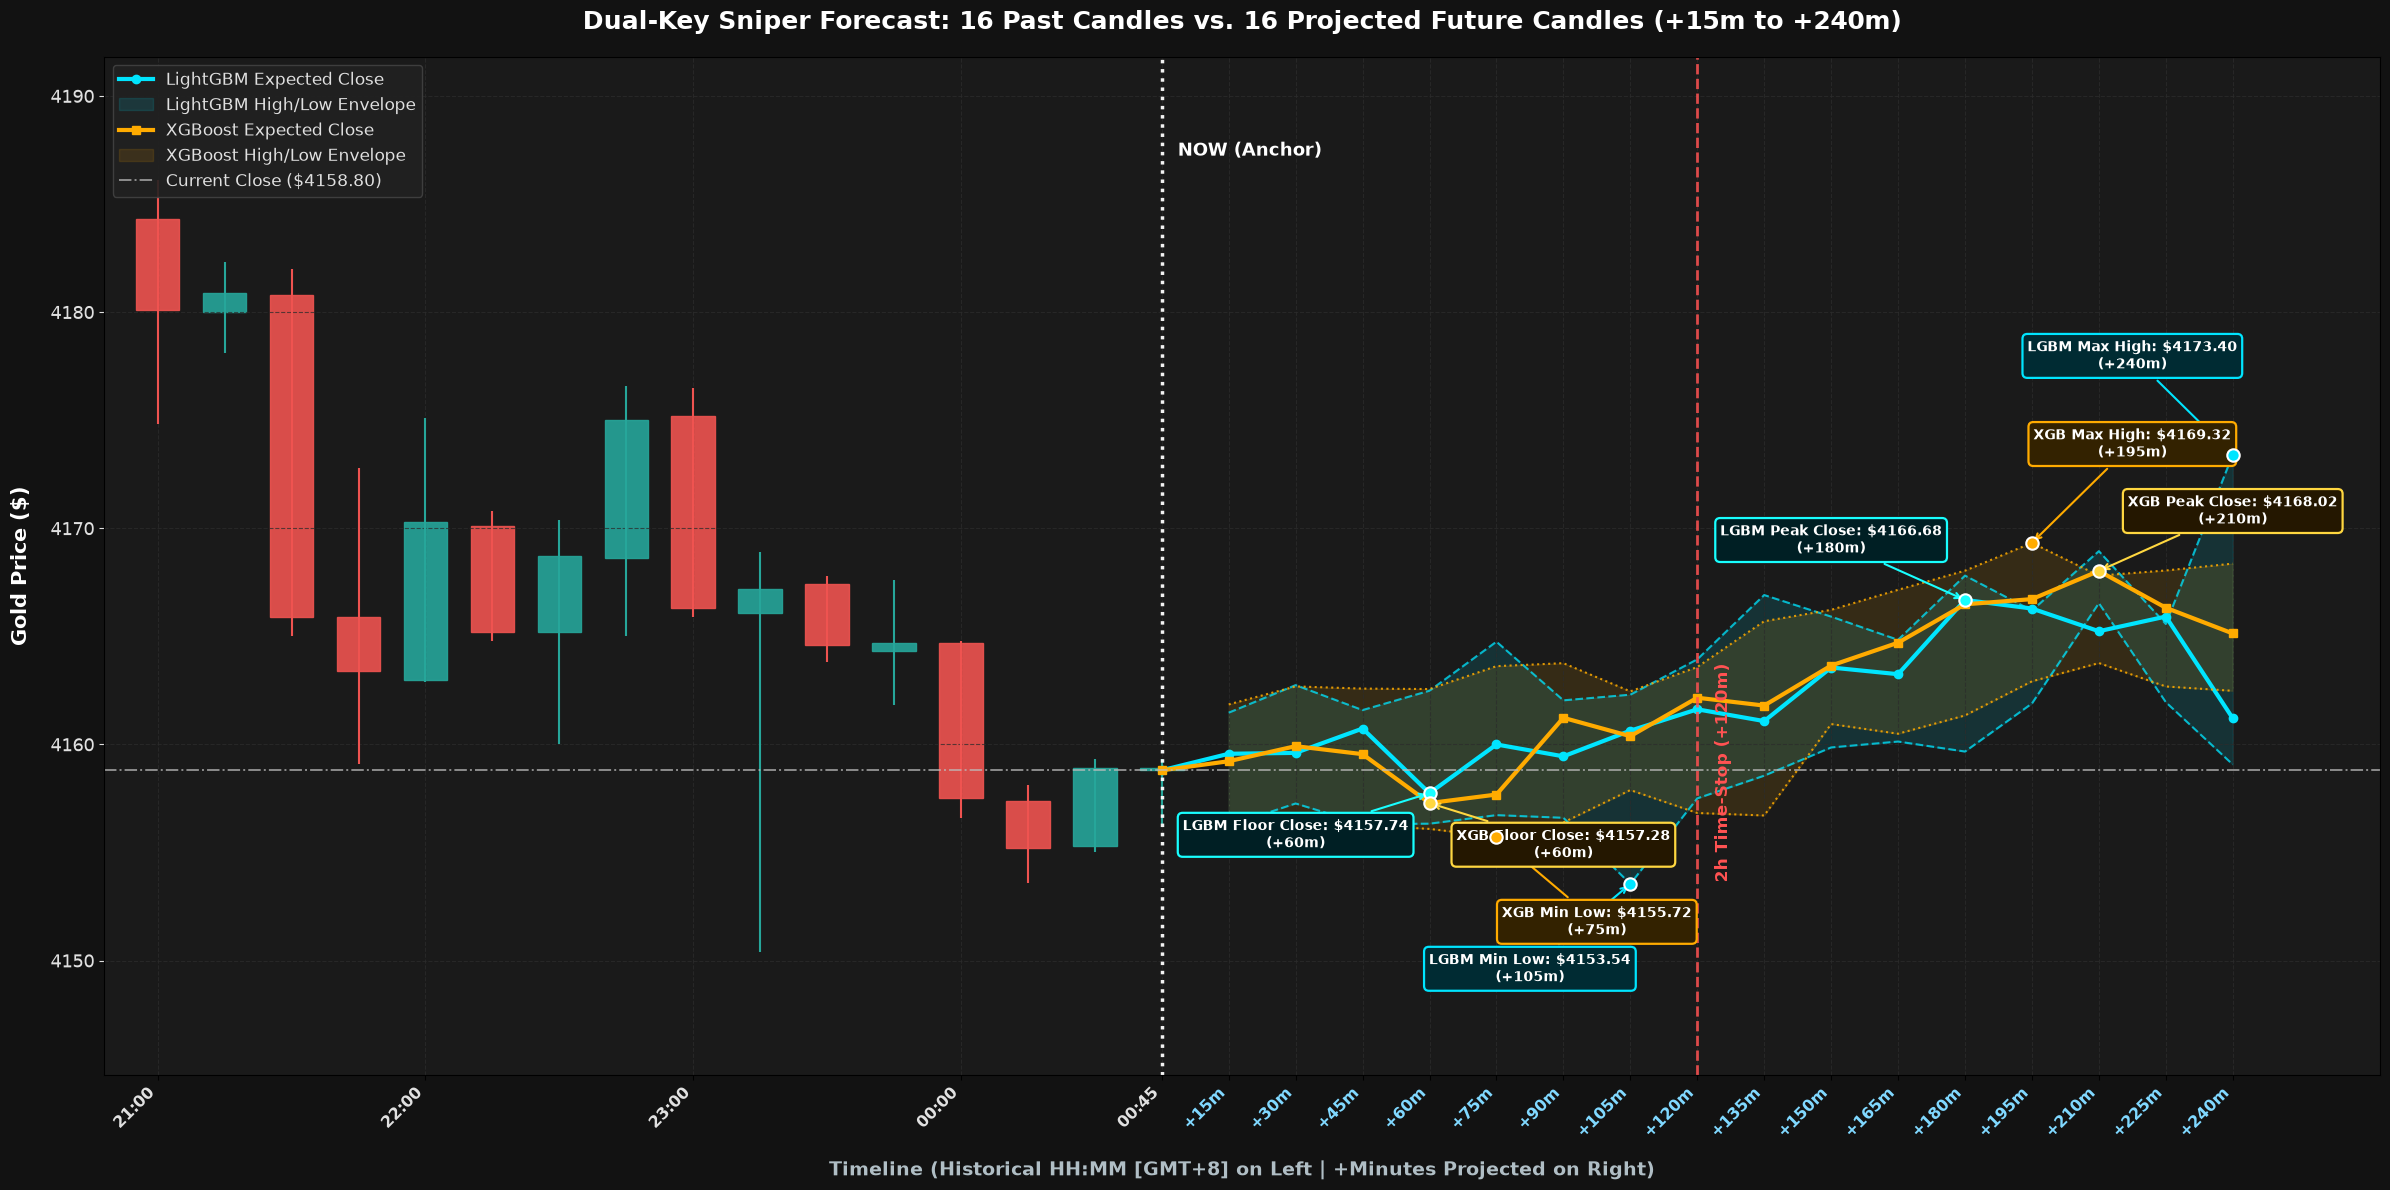


8 INDEPENDENT MODEL BENCHMARK EXTREMES (NEXT 4 HOURS)
1. LightGBM Max High:    $4173.40  (at +240m)
2. XGBoost  Max High:    $4169.32  (at +195m)
3. LightGBM Min Low:     $4153.54  (at +105m)
4. XGBoost  Min Low:     $4155.72  (at +75m)
5. LightGBM Peak Close:  $4166.68  (at +180m)
6. XGBoost  Peak Close:  $4168.02  (at +210m)
7. LightGBM Floor Close: $4157.74  (at +60m)
8. XGBoost  Floor Close: $4157.28  (at +60m)


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =======================================================
# 1. 16 HISTORICAL BARS + 16 FORECASTED BARS (GMT+8)
# =======================================================
hist_len = 16  # Exactly 16 past candles (4 hours)
hist_df = master_df.tail(hist_len).copy()
current_gold_close = hist_df['Gold_Close'].iloc[-1]

# Convert index to GMT+8 (Asia/Singapore / Manila / Hong Kong)
if hist_df.index.tz is None:
    hist_index_gmt8 = hist_df.index.tz_localize('UTC').tz_convert('Asia/Singapore')
else:
    hist_index_gmt8 = hist_df.index.tz_convert('Asia/Singapore')

# 16 future indices: from 16 to 31
future_indices = list(range(hist_len, hist_len + 16))

# LightGBM paths
lgbm_proj_high  = [current_gold_close + lgbm_highs[i] for i in range(16)]
lgbm_proj_low   = [current_gold_close + lgbm_lows[i]  for i in range(16)]
lgbm_proj_close = [current_gold_close + lgbm_close[i] for i in range(16)]

# XGBoost paths
xgb_proj_high  = [current_gold_close + xgb_highs[i] for i in range(16)]
xgb_proj_low   = [current_gold_close + xgb_lows[i]  for i in range(16)]
xgb_proj_close = [current_gold_close + xgb_close[i] for i in range(16)]

# Shared connection from current close into future
x_conn = [hist_len - 1] + future_indices
y_lgbm_close_conn = [current_gold_close] + lgbm_proj_close
y_xgb_close_conn  = [current_gold_close] + xgb_proj_close

# =======================================================
# 2. IDENTIFY 8 INDEPENDENT EXTREME POINTS (4 PER MODEL)
# =======================================================
# Helper to find (x_idx, price, minute_offset)
def get_extreme(val_list, mode='max'):
    idx = int(np.argmax(val_list) if mode == 'max' else np.argmin(val_list))
    return future_indices[idx], val_list[idx], (idx + 1) * 15

# LightGBM 4 Extremes
lgbm_max_high  = get_extreme(lgbm_proj_high, 'max')
lgbm_min_low   = get_extreme(lgbm_proj_low, 'min')
lgbm_max_close = get_extreme(lgbm_proj_close, 'max')
lgbm_min_close = get_extreme(lgbm_proj_close, 'min')

# XGBoost 4 Extremes
xgb_max_high  = get_extreme(xgb_proj_high, 'max')
xgb_min_low   = get_extreme(xgb_proj_low, 'min')
xgb_max_close = get_extreme(xgb_proj_close, 'max')
xgb_min_close = get_extreme(xgb_proj_close, 'min')

# =======================================================
# 3. PLOT CANVAS (LARGE TYPOGRAPHY + GMT+8)
# =======================================================
fig, ax = plt.subplots(figsize=(24, 12), facecolor='#121212')
ax.set_facecolor('#1a1a1a')

# A. Historical Candles
bar_width = 0.65
for i in range(hist_len):
    row = hist_df.iloc[i]
    is_up = row['Gold_Close'] >= row['Gold_Open']
    c_color = '#26a69a' if is_up else '#ef5350'
    
    # Wick
    ax.vlines(x=i, ymin=row['Gold_Low'], ymax=row['Gold_High'], color=c_color, linewidth=1.5)
    # Body
    b_bottom = min(row['Gold_Open'], row['Gold_Close'])
    b_height = max(abs(row['Gold_Close'] - row['Gold_Open']), 0.1)
    rect = patches.Rectangle((i - bar_width/2, b_bottom), bar_width, b_height, 
                             facecolor=c_color, edgecolor=c_color, alpha=0.9)
    ax.add_patch(rect)

# B. Anchor Line (NOW)
ax.axvline(x=hist_len - 1, color='#ffffff', linestyle=':', linewidth=2.5, alpha=0.95)
ax.text(hist_len - 0.85, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else current_gold_close + 12, 
        ' NOW (Anchor)', color='#ffffff', fontsize=13, fontweight='bold', va='top')

# C. LightGBM Trajectory & High/Low Envelope (Cyan)
LGBM_COLOR = '#00e5ff'
ax.plot(x_conn, y_lgbm_close_conn, color=LGBM_COLOR, linewidth=3.0, 
        marker='o', markersize=6, label='LightGBM Expected Close')
ax.plot(future_indices, lgbm_proj_high, color=LGBM_COLOR, linestyle='--', linewidth=1.5, alpha=0.75)
ax.plot(future_indices, lgbm_proj_low,  color=LGBM_COLOR, linestyle='--', linewidth=1.5, alpha=0.75)
ax.fill_between(future_indices, lgbm_proj_low, lgbm_proj_high, 
                color=LGBM_COLOR, alpha=0.12, label='LightGBM High/Low Envelope')

# D. XGBoost Trajectory & High/Low Envelope (Amber Gold)
XGB_COLOR = '#ffab00'
ax.plot(x_conn, y_xgb_close_conn, color=XGB_COLOR, linewidth=3.0, 
        marker='s', markersize=6, label='XGBoost Expected Close')
ax.plot(future_indices, xgb_proj_high, color=XGB_COLOR, linestyle=':', linewidth=1.5, alpha=0.85)
ax.plot(future_indices, xgb_proj_low,  color=XGB_COLOR, linestyle=':', linewidth=1.5, alpha=0.85)
ax.fill_between(future_indices, xgb_proj_low, xgb_proj_high, 
                color=XGB_COLOR, alpha=0.12, label='XGBoost High/Low Envelope')

# E. 2-Hour Time Stop Milestone (Bar #8 / +120m)
time_stop_x = hist_len + 7
ax.axvline(x=time_stop_x, color='#ff5252', linestyle='--', linewidth=2.0, alpha=0.85)
ax.text(time_stop_x + 0.25, current_gold_close - 5.0, '2h Time-Stop (+120m)', 
        color='#ff5252', fontsize=12, fontweight='bold', rotation=90)

# F. Horizontal Baseline Reference
ax.axhline(y=current_gold_close, color='#bdbdbd', linestyle='-.', linewidth=1.4, alpha=0.7, 
           label=f'Current Close (${current_gold_close:.2f})')

# =======================================================
# 4. ANNOTATE ALL 8 EXTREME POINTS (4 LGBM & 4 XGB)
# =======================================================
# Helper for clean callout placement
def draw_callout(x, y, text, box_color, border_color, xytext_offset, arrow_color):
    ax.scatter(x, y, color=border_color, s=80, zorder=6, edgecolor='#ffffff', linewidth=1.5)
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(x + xytext_offset[0], y + xytext_offset[1]),
        bbox=dict(boxstyle="round,pad=0.35", fc=box_color, ec=border_color, lw=1.6),
        arrowprops=dict(arrowstyle="->", color=arrow_color, lw=1.5),
        color="#ffffff", fontsize=10, fontweight="bold", ha='center'
    )

# --- 4 LIGHTGBM POINTS (Cyan Theme) ---
# 1. LGBM Highest High
draw_callout(lgbm_max_high[0], lgbm_max_high[1], 
             f"LGBM Max High: ${lgbm_max_high[1]:.2f}\n(+{lgbm_max_high[2]}m)", 
             box_color="#002b33", border_color="#00e5ff", xytext_offset=(-1.5, 4.0), arrow_color="#00e5ff")

# 2. LGBM Lowest Low
draw_callout(lgbm_min_low[0], lgbm_min_low[1], 
             f"LGBM Min Low: ${lgbm_min_low[1]:.2f}\n(+{lgbm_min_low[2]}m)", 
             box_color="#002b33", border_color="#00e5ff", xytext_offset=(-1.5, -4.5), arrow_color="#00e5ff")

# 3. LGBM Highest Close
draw_callout(lgbm_max_close[0], lgbm_max_close[1], 
             f"LGBM Peak Close: ${lgbm_max_close[1]:.2f}\n(+{lgbm_max_close[2]}m)", 
             box_color="#001f24", border_color="#18ffff", xytext_offset=(-2.0, 2.2), arrow_color="#18ffff")

# 4. LGBM Lowest Close
draw_callout(lgbm_min_close[0], lgbm_min_close[1], 
             f"LGBM Floor Close: ${lgbm_min_close[1]:.2f}\n(+{lgbm_min_close[2]}m)", 
             box_color="#001f24", border_color="#18ffff", xytext_offset=(-2.0, -2.5), arrow_color="#18ffff")

# --- 4 XGBOOST POINTS (Amber Theme) ---
# 5. XGB Highest High
draw_callout(xgb_max_high[0], xgb_max_high[1], 
             f"XGB Max High: ${xgb_max_high[1]:.2f}\n(+{xgb_max_high[2]}m)", 
             box_color="#332200", border_color="#ffab00", xytext_offset=(1.5, 4.0), arrow_color="#ffab00")

# 6. XGB Lowest Low
draw_callout(xgb_min_low[0], xgb_min_low[1], 
             f"XGB Min Low: ${xgb_min_low[1]:.2f}\n(+{xgb_min_low[2]}m)", 
             box_color="#332200", border_color="#ffab00", xytext_offset=(1.5, -4.5), arrow_color="#ffab00")

# 7. XGB Highest Close
draw_callout(xgb_max_close[0], xgb_max_close[1], 
             f"XGB Peak Close: ${xgb_max_close[1]:.2f}\n(+{xgb_max_close[2]}m)", 
             box_color="#241700", border_color="#ffd740", xytext_offset=(2.0, 2.2), arrow_color="#ffd740")

# 8. XGB Lowest Close
draw_callout(xgb_min_close[0], xgb_min_close[1], 
             f"XGB Floor Close: ${xgb_min_close[1]:.2f}\n(+{xgb_min_close[2]}m)", 
             box_color="#241700", border_color="#ffd740", xytext_offset=(2.0, -2.5), arrow_color="#ffd740")

# Expand Y-limits comfortably to prevent any callout clipping
all_y_extremes = [lgbm_max_high[1], xgb_max_high[1], lgbm_min_low[1], xgb_min_low[1], 
                  hist_df['Gold_Low'].min(), hist_df['Gold_High'].max()]
y_span = max(all_y_extremes) - min(all_y_extremes)
ax.set_ylim(min(all_y_extremes) - y_span * 0.16, max(all_y_extremes) + y_span * 0.16)

# =======================================================
# 5. ENHANCED AXES & LABELS (GMT+8)
# =======================================================
total_bars = hist_len + 16
ax.set_xlim(-0.8, total_bars + 1.2)

# Historical ticks converted to GMT+8
hist_ticks = [0, 4, 8, 12, 15]
hist_labels = [hist_index_gmt8[idx].strftime('%H:%M') for idx in hist_ticks]

# Future forecast ticks: EVERY SINGLE BAR (+15m to +240m)
future_ticks = list(range(hist_len, total_bars))
future_labels = [f"+{(step + 1) * 15}m" for step in range(16)]

all_ticks = hist_ticks + future_ticks
all_labels = hist_labels + future_labels

ax.set_xticks(all_ticks)
ax.set_xticklabels(all_labels, color='#e0e0e0', fontsize=11.5, fontweight='bold', rotation=45, ha='right')
ax.tick_params(axis='y', colors='#e0e0e0', labelsize=13)

# Highlight future labels in vivid blue
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    if tick >= hist_len:
        label.set_color('#80d8ff')

# Titles and Axis Labels
ax.set_title("Dual-Key Sniper Forecast: 16 Past Candles vs. 16 Projected Future Candles (+15m to +240m)", 
             color='#ffffff', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel("Gold Price ($)", color='#ffffff', fontsize=15, fontweight='bold', labelpad=14)
ax.set_xlabel("Timeline (Historical HH:MM [GMT+8] on Left | +Minutes Projected on Right)", 
              color='#b0bec5', fontsize=14, fontweight='bold', labelpad=14)

# Grid & Legend
ax.grid(True, color='#2c2c2c', linestyle='--', linewidth=0.8, alpha=0.75)
ax.legend(facecolor='#212121', edgecolor='#424242', labelcolor='#e0e0e0', 
          loc='upper left', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

# =======================================================
# 6. QUICK BENCHMARK PRINT CARD OF ALL 8 POINTS
# =======================================================
print("\n" + "="*80)
print("8 INDEPENDENT MODEL BENCHMARK EXTREMES (NEXT 4 HOURS)")
print("="*80)
print(f"1. LightGBM Max High:    ${lgbm_max_high[1]:.2f}  (at +{lgbm_max_high[2]}m)")
print(f"2. XGBoost  Max High:    ${xgb_max_high[1]:.2f}  (at +{xgb_max_high[2]}m)")
print(f"3. LightGBM Min Low:     ${lgbm_min_low[1]:.2f}  (at +{lgbm_min_low[2]}m)")
print(f"4. XGBoost  Min Low:     ${xgb_min_low[1]:.2f}  (at +{xgb_min_low[2]}m)")
print(f"5. LightGBM Peak Close:  ${lgbm_max_close[1]:.2f}  (at +{lgbm_max_close[2]}m)")
print(f"6. XGBoost  Peak Close:  ${xgb_max_close[1]:.2f}  (at +{xgb_max_close[2]}m)")
print(f"7. LightGBM Floor Close: ${lgbm_min_close[1]:.2f}  (at +{lgbm_min_close[2]}m)")
print(f"8. XGBoost  Floor Close: ${xgb_min_close[1]:.2f}  (at +{xgb_min_close[2]}m)")
print("="*80)
